In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
gmst = pd.read_csv("GMST.csv",header=None,names=['gmst'])
gmst

,gmst
0,-0.25056
1,-0.34636
2,-0.13468
3,-0.21151
4,-0.13327
...,...
1731,1.32010
1732,1.15760
1733,1.22760
1734,1.22940


In [4]:
gmst.loc[[1,2,3]]

,gmst
1,-0.34636
2,-0.13468
3,-0.21151


In [5]:
import matplotlib.pyplot as plt

# 在绘图前设置全局样式
# 推荐的科研/出版样式:
plt.style.use('seaborn-v0_8-paper')  # 紧凑，适合论文
# 或者
# plt.style.use('seaborn-v0_8-whitegrid') # 带有白色网格，清晰
# 或者
# plt.style.use('ggplot') # R语言中流行的样式

# 也可以自定义字体大小等参数
plt.rcParams['font.family'] = 'sans-serif' # 使用无衬线字体
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica'] # 优先使用Arial
plt.rcParams['axes.labelsize'] = 12 # 坐标轴标签字号
plt.rcParams['xtick.labelsize'] = 10 # x轴刻度字号
plt.rcParams['ytick.labelsize'] = 10 # y轴刻度字号
plt.rcParams['legend.fontsize'] = 10 # 图例字号
plt.rcParams['figure.dpi'] = 300 # 提高图像分辨率

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def guodianplotnmoth_ax(df, n,ax):
    # 检查输入有效性
    if not isinstance(n, int) or n <= 0:
        raise ValueError("参数 n 必须是正整数")
    if len(df) < 2:
        raise ValueError("数据长度不足以分割，至少需要2行数据")
    
    # 生成位置索引
    id1 = np.arange(0, len(df), n)
    id2 = np.arange(n, len(df), n)
    
    # 确保 id1 和 id2 长度一致（避免越界）
    min_length = min(len(id1), len(id2))
    id1 = id1[:min_length]
    id2 = id2[:min_length]
    
    # 按位置选择行并相加（假设处理单列数据）
    if df.shape[1] != 1:
        raise ValueError("该函数仅适用于单列数据")
    
    summed_values = df.iloc[id1].values + df.iloc[id2].values
    df1 = pd.DataFrame(summed_values, columns=[f'gmst_{n}'])
    
    # 生成每月初的时间戳索引（间隔为n个月）
    dates = pd.date_range(
        start="1880-01-01",
        periods=len(id1),
        freq=f"{n}MS"  # 例如 n=2 时生成每两个月的月初
    )
    
    # 设置索引并绘图
    df1.index = dates
    df1.plot(ax=ax)
    ax.set_title(f'Plot with n = {n}')
    ax.set_xlabel('year')
    ax.set_ylabel('gmst')
    


In [ ]:
guodianplotnmoth_ax(gmst,1)

NameError: name 'guodianplotnmoth' is not defined

## 绘制多时间段子图

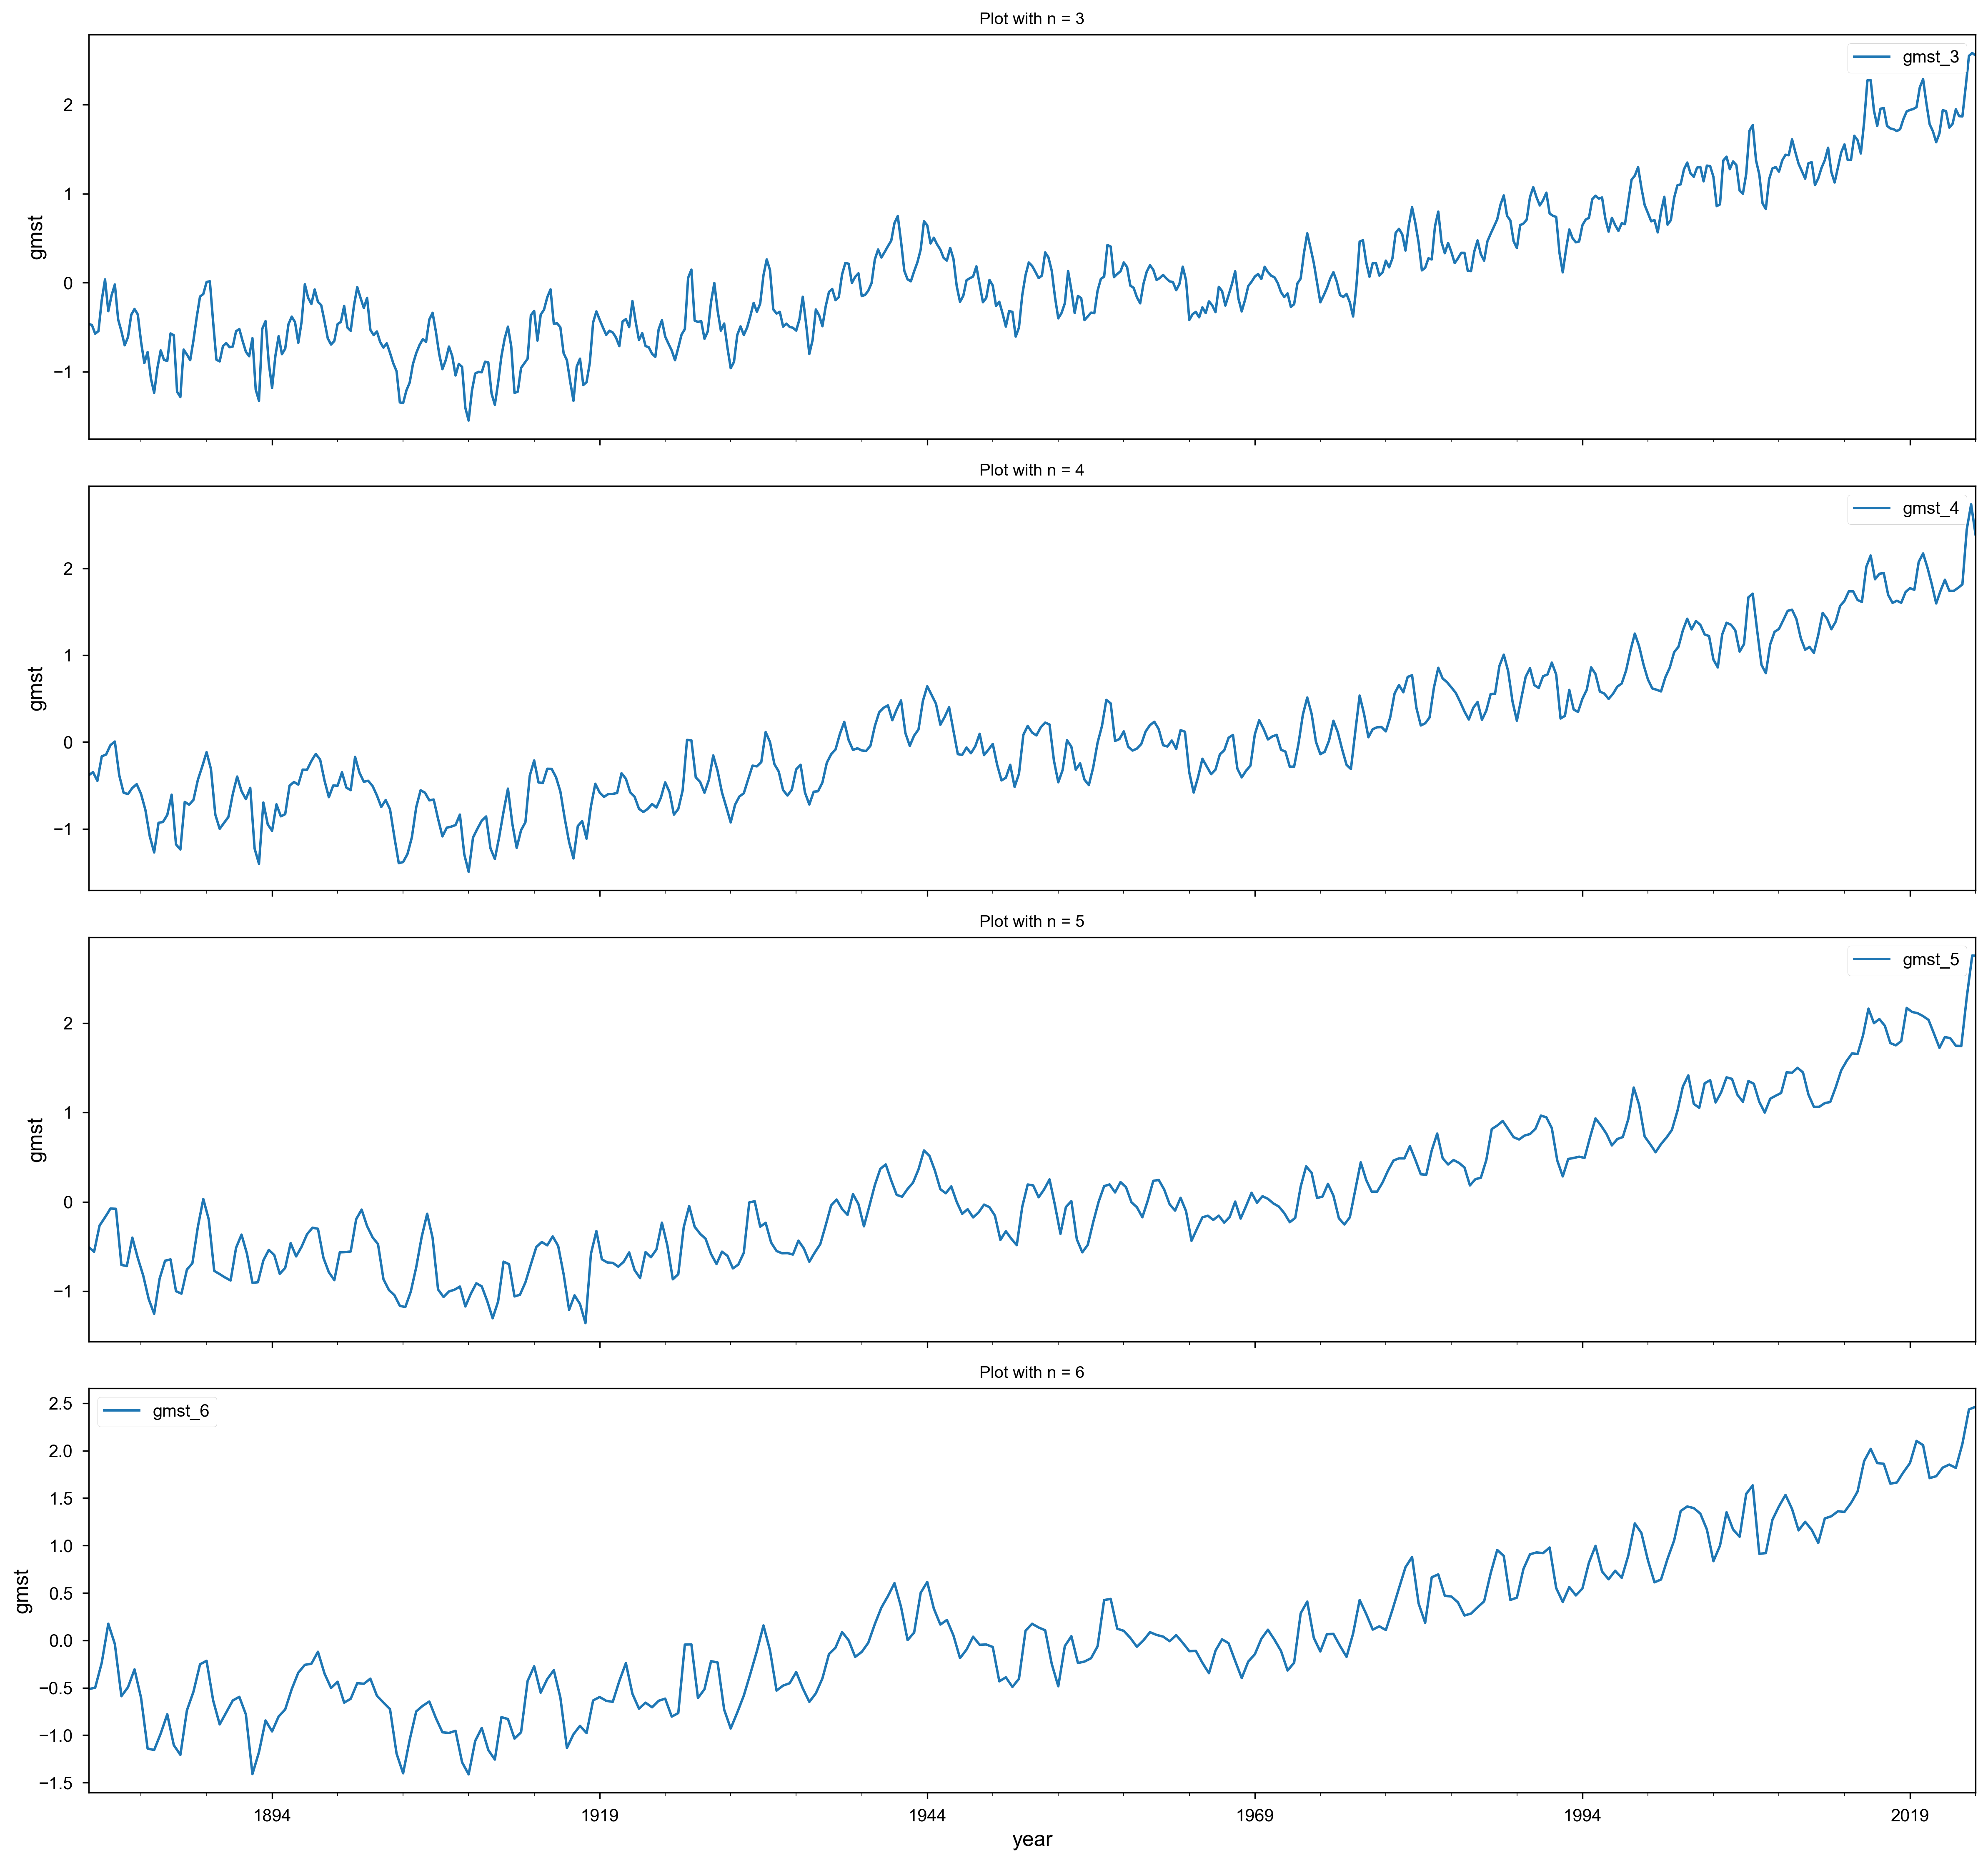

In [8]:
fig,axes = plt.subplots(4,1, figsize=(16, 15), sharex=True)
guodianplotnmoth_ax(gmst,3,axes[0])
guodianplotnmoth_ax(gmst,4,axes[1])
guodianplotnmoth_ax(gmst,5,axes[2])
guodianplotnmoth_ax(gmst,6,axes[3])
plt.tight_layout() # 自动调整子图间距
plt.show()

## 绘制优秀图


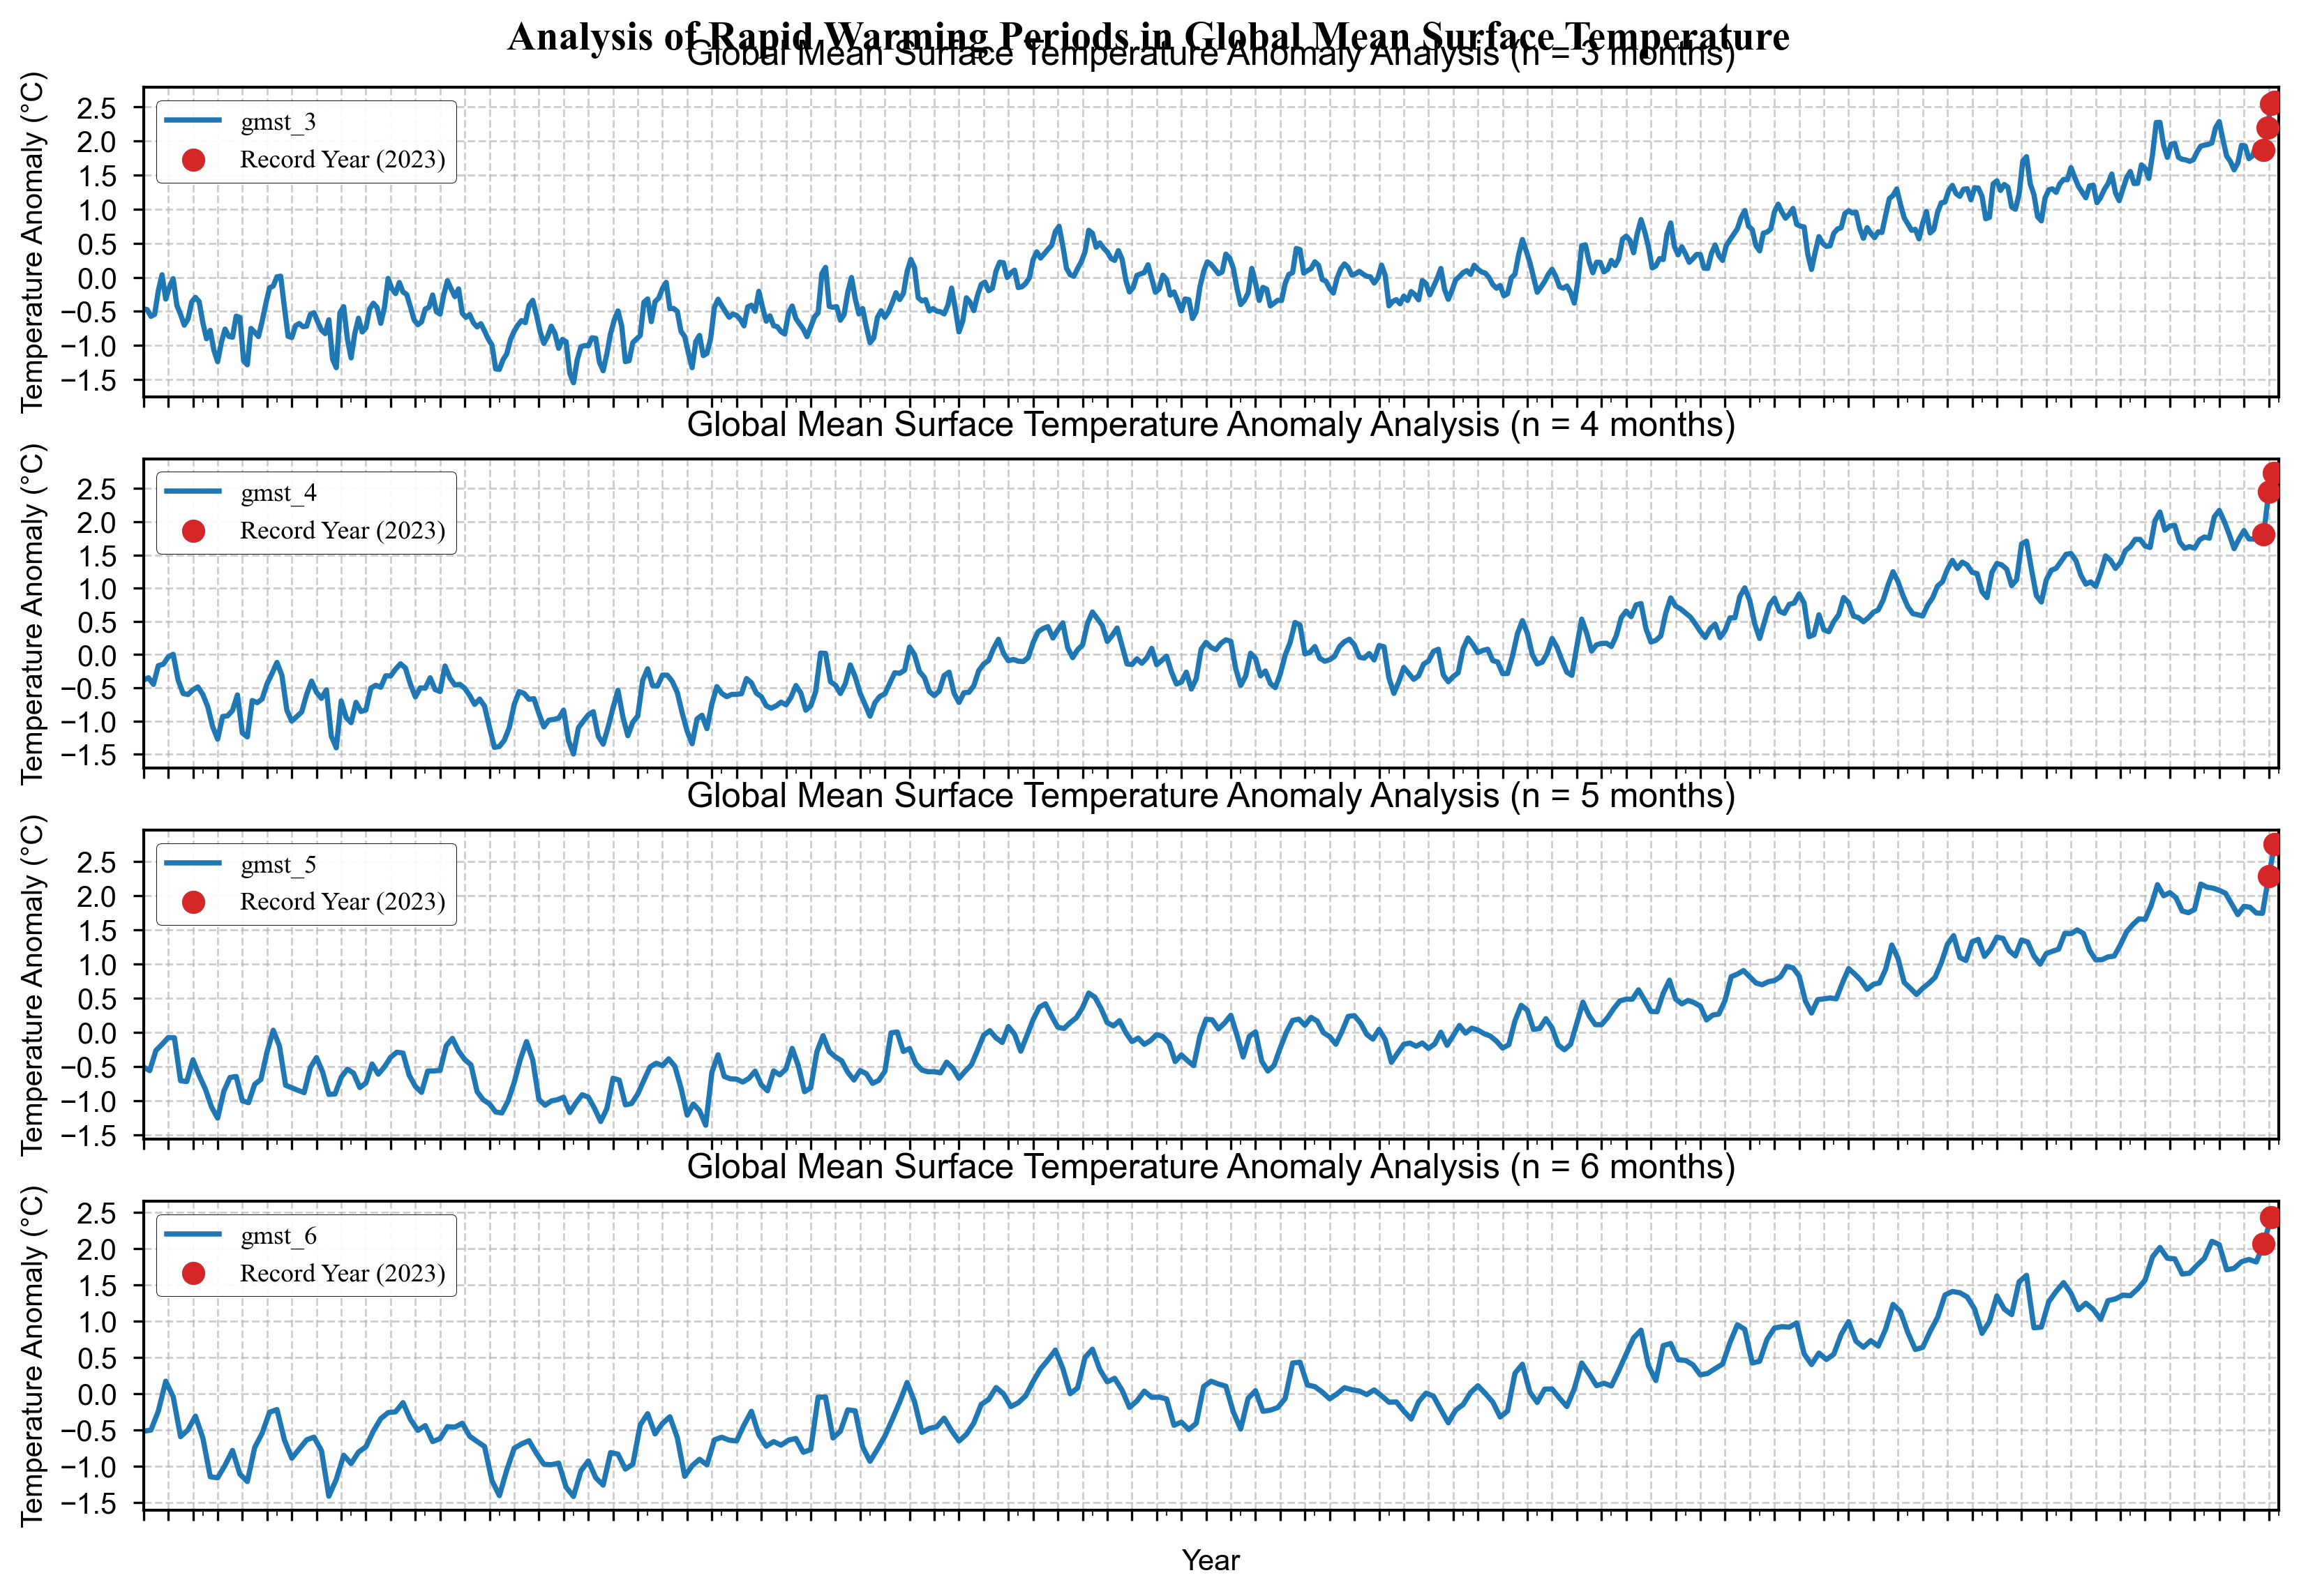

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl

def guodianplotnmoth_ax(df, n, ax):
    """
    分析全球地表温度数据中的突变特征，并在指定的axes对象上绘制结果。
    
    该函数通过计算间隔为n个月的数据点之和，识别温度序列中的快速变化期。
    
    参数:
    df -- 时间序列数据 (单列DataFrame)，索引应为时间序列
    n -- 时间间隔(月)，用于计算突变特征
    ax -- matplotlib轴对象，用于绘制图表
    
    返回:
    matplotlib.lines.Line2D对象
    """
    # 检查输入有效性
    if not isinstance(n, int) or n <= 0:
        raise ValueError("参数 n 必须是正整数")
    if len(df) < 2 * n:  # 需要至少2n个数据点才能进行计算
        raise ValueError(f"数据长度不足以分割，至少需要{2*n}行数据")
    if df.shape[1] != 1:
        raise ValueError("该函数仅适用于单列数据")
    
    # 生成位置索引
    id1 = np.arange(0, len(df) - n, n)
    id2 = np.arange(n, len(df), n)
    
    # 确保 id1 和 id2 长度一致
    min_length = min(len(id1), len(id2))
    id1 = id1[:min_length]
    id2 = id2[:min_length]
    
    # 计算突变值
    summed_values = df.iloc[id1].values + df.iloc[id2].values
    df1 = pd.DataFrame(summed_values, columns=[f'gmst_{n}'])
    
    # 生成时间戳索引
    dates = pd.date_range(
        start="1880-01-01",
        periods=len(id1),
        freq=f"{n}MS"
    )
    
    # 设置索引
    df1.index = dates
    
    # 设置科研级图表样式
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Times New Roman']
    
    # 定义专业配色
    primary_color = '#1f77b4'  # 蓝色 - 主要数据线
    highlight_color = '#d62728'  # 红色 - 2023年高亮
    
    # 绘制数据
    line = df1.plot(ax=ax, color=primary_color, linewidth=1.8)
    
    # 标记2023年（如果数据包含）
    if (df1.index.year == 2023).any():
        peak_idx = df1.index.year == 2023
        ax.scatter(df1.index[peak_idx], df1[peak_idx], 
                  color=highlight_color, s=60, zorder=5,
                  label='Record Year (2023)')
    
    # 设置标题和标签
    ax.set_title(f'Global Mean Surface Temperature Anomaly Analysis (n = {n} months)', 
                 fontsize=12, pad=8)
    ax.set_ylabel('Temperature Anomaly (°C)', fontsize=10)
    
    # 优化坐标轴
    ax.xaxis.set_major_locator(MultipleLocator(base=20))  # 每20年一个主要刻度
    ax.yaxis.set_major_locator(MultipleLocator(base=0.5))
    
    # 添加网格线
    ax.grid(True, linestyle='--', alpha=0.6, linewidth=0.7)
    
    # 设置背景为白色
    ax.set_facecolor('white')
    
    # 添加图例（如果需要）
    if (df1.index.year == 2023).any():
        ax.legend(loc='best', frameon=True, facecolor='white', 
                 edgecolor='black', framealpha=0.9)
    
    # 设置边框
    for spine in ax.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1.0)
    
    return line

# 创建图表
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

# 应用科研级图形参数
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0
})

# 绘制不同n值的图表
guodianplotnmoth_ax(gmst, 1, axes[0])
guodianplotnmoth_ax(gmst, 4, axes[1])
guodianplotnmoth_ax(gmst, 5, axes[2])
guodianplotnmoth_ax(gmst, 6, axes[3])

# 添加总体标题
plt.suptitle('Analysis of Rapid Warming Periods in Global Mean Surface Temperature', 
             fontsize=14, fontweight='bold', y=0.97)

# 调整子图间距
plt.subplots_adjust(hspace=0.2, top=0.93, bottom=0.08, left=0.1, right=0.95)

# 添加x轴标签（只在最下面的图显示）
axes[-1].set_xlabel('Year', fontsize=10)

# 保存高分辨率图像
plt.savefig('global_temperature_rapid_warming_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('global_temperature_rapid_warming_analysis.pdf', dpi=300, bbox_inches='tight')

plt.show()

In [12]:
def guodianplotnmoth2(df, n):
    # 检查输入有效性
    if not isinstance(n, int) or n <= 0:
        raise ValueError("参数 n 必须是正整数")
    if len(df) < 2:
        raise ValueError("数据长度不足以分割，至少需要2行数据")
    
    # 生成位置索引
    id1 = np.arange(0, len(df), n)
    id2 = np.arange(n, len(df), n)
    
    # 确保 id1 和 id2 长度一致（避免越界）
    min_length = min(len(id1), len(id2))
    id1 = id1[:min_length]
    id2 = id2[:min_length]
    
    # 按位置选择行并相加（假设处理单列数据）
    if df.shape[1] != 1:
        raise ValueError("该函数仅适用于单列数据")
    
    summed_values = df.iloc[id1].values + df.iloc[id2].values
    df1 = pd.DataFrame(summed_values, columns=[f'gmst_{n}'])
    
    # 生成每月初的时间戳索引（间隔为n个月）
    dates = pd.date_range(
        start="1880-01-01",
        periods=len(id1),
        freq=f"{n}MS"  # 例如 n=2 时生成每两个月的月初
    )
    
    # 设置索引并绘图
    df1.index = dates
    ax = plt.figure()
    df1.plot(title=f'{n}', figsize=(10, 5))
    plt.show()
    
    return ax

In [14]:
def yuessd(df):
    id1 = np.arange(0, 12)
    id2 = np.arange(0,len(df)/12)
    id3 = np.zeros([id2,1])
    for i in id2:
        for j in id1:
            id3[i]+=df.iloc[12*i+j]
    

<Figure size 640x480 with 0 Axes>

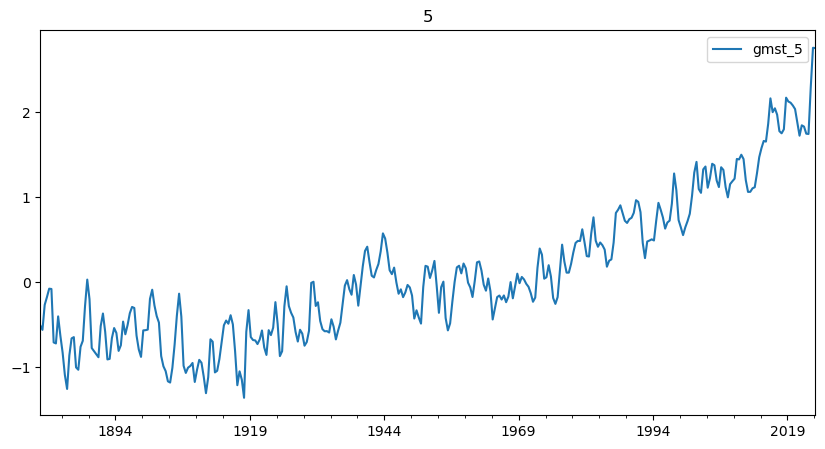

<Figure size 640x480 with 0 Axes>

In [16]:
guodianplotnmoth(gmst,5)

In [21]:
gmst30 = pd.read_excel("工作簿1.xlsx",header=None)
gmst30 = gmst30.T
gmst30.shape
date30 = pd.date_range(start="1880-1-1",freq="MS",periods=len(gmst30))
gmst30.index = date30

gmst30.columns = ['gmst30']
gmst30.columns.values[0]

'gmst30'

In [22]:
import matplotlib.pyplot as plt

def plotgmst(df,df2,n):
    # 创建figure和axes对象（面向对象风格）
    fig, ax = plt.subplots(figsize=(12, 6))  # 添加合理的画布尺寸
    
    # 绘制数据（明确指定label参数）
    ax.plot(df.index, df.iloc[:, 0], 
            linewidth=1, 
            color='#75bbfd',
            label=df.columns[0])  # 关键改进：使用label参数
    if(n):
        ax.scatter(df2.index,df2,s = 1.0,c  = 'red')  
    # 设置刻度参数（正确作用于axes对象）
    ax.tick_params(
        which='major',
        width=1.0,
        labelsize=12,
        length=10
    )
    
    # 添加图例（自动获取label）
    ax.legend(loc='best')  # 自动获取plot时设置的label
    
    # 添加轴标签和标题（提升可读性）
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Temperature', fontsize=12)
    ax.set_title(f'{df.columns[0]} Variation', fontsize=14)
    
    plt.tight_layout()  # 自动调整布局
    plt.show()
    return ax

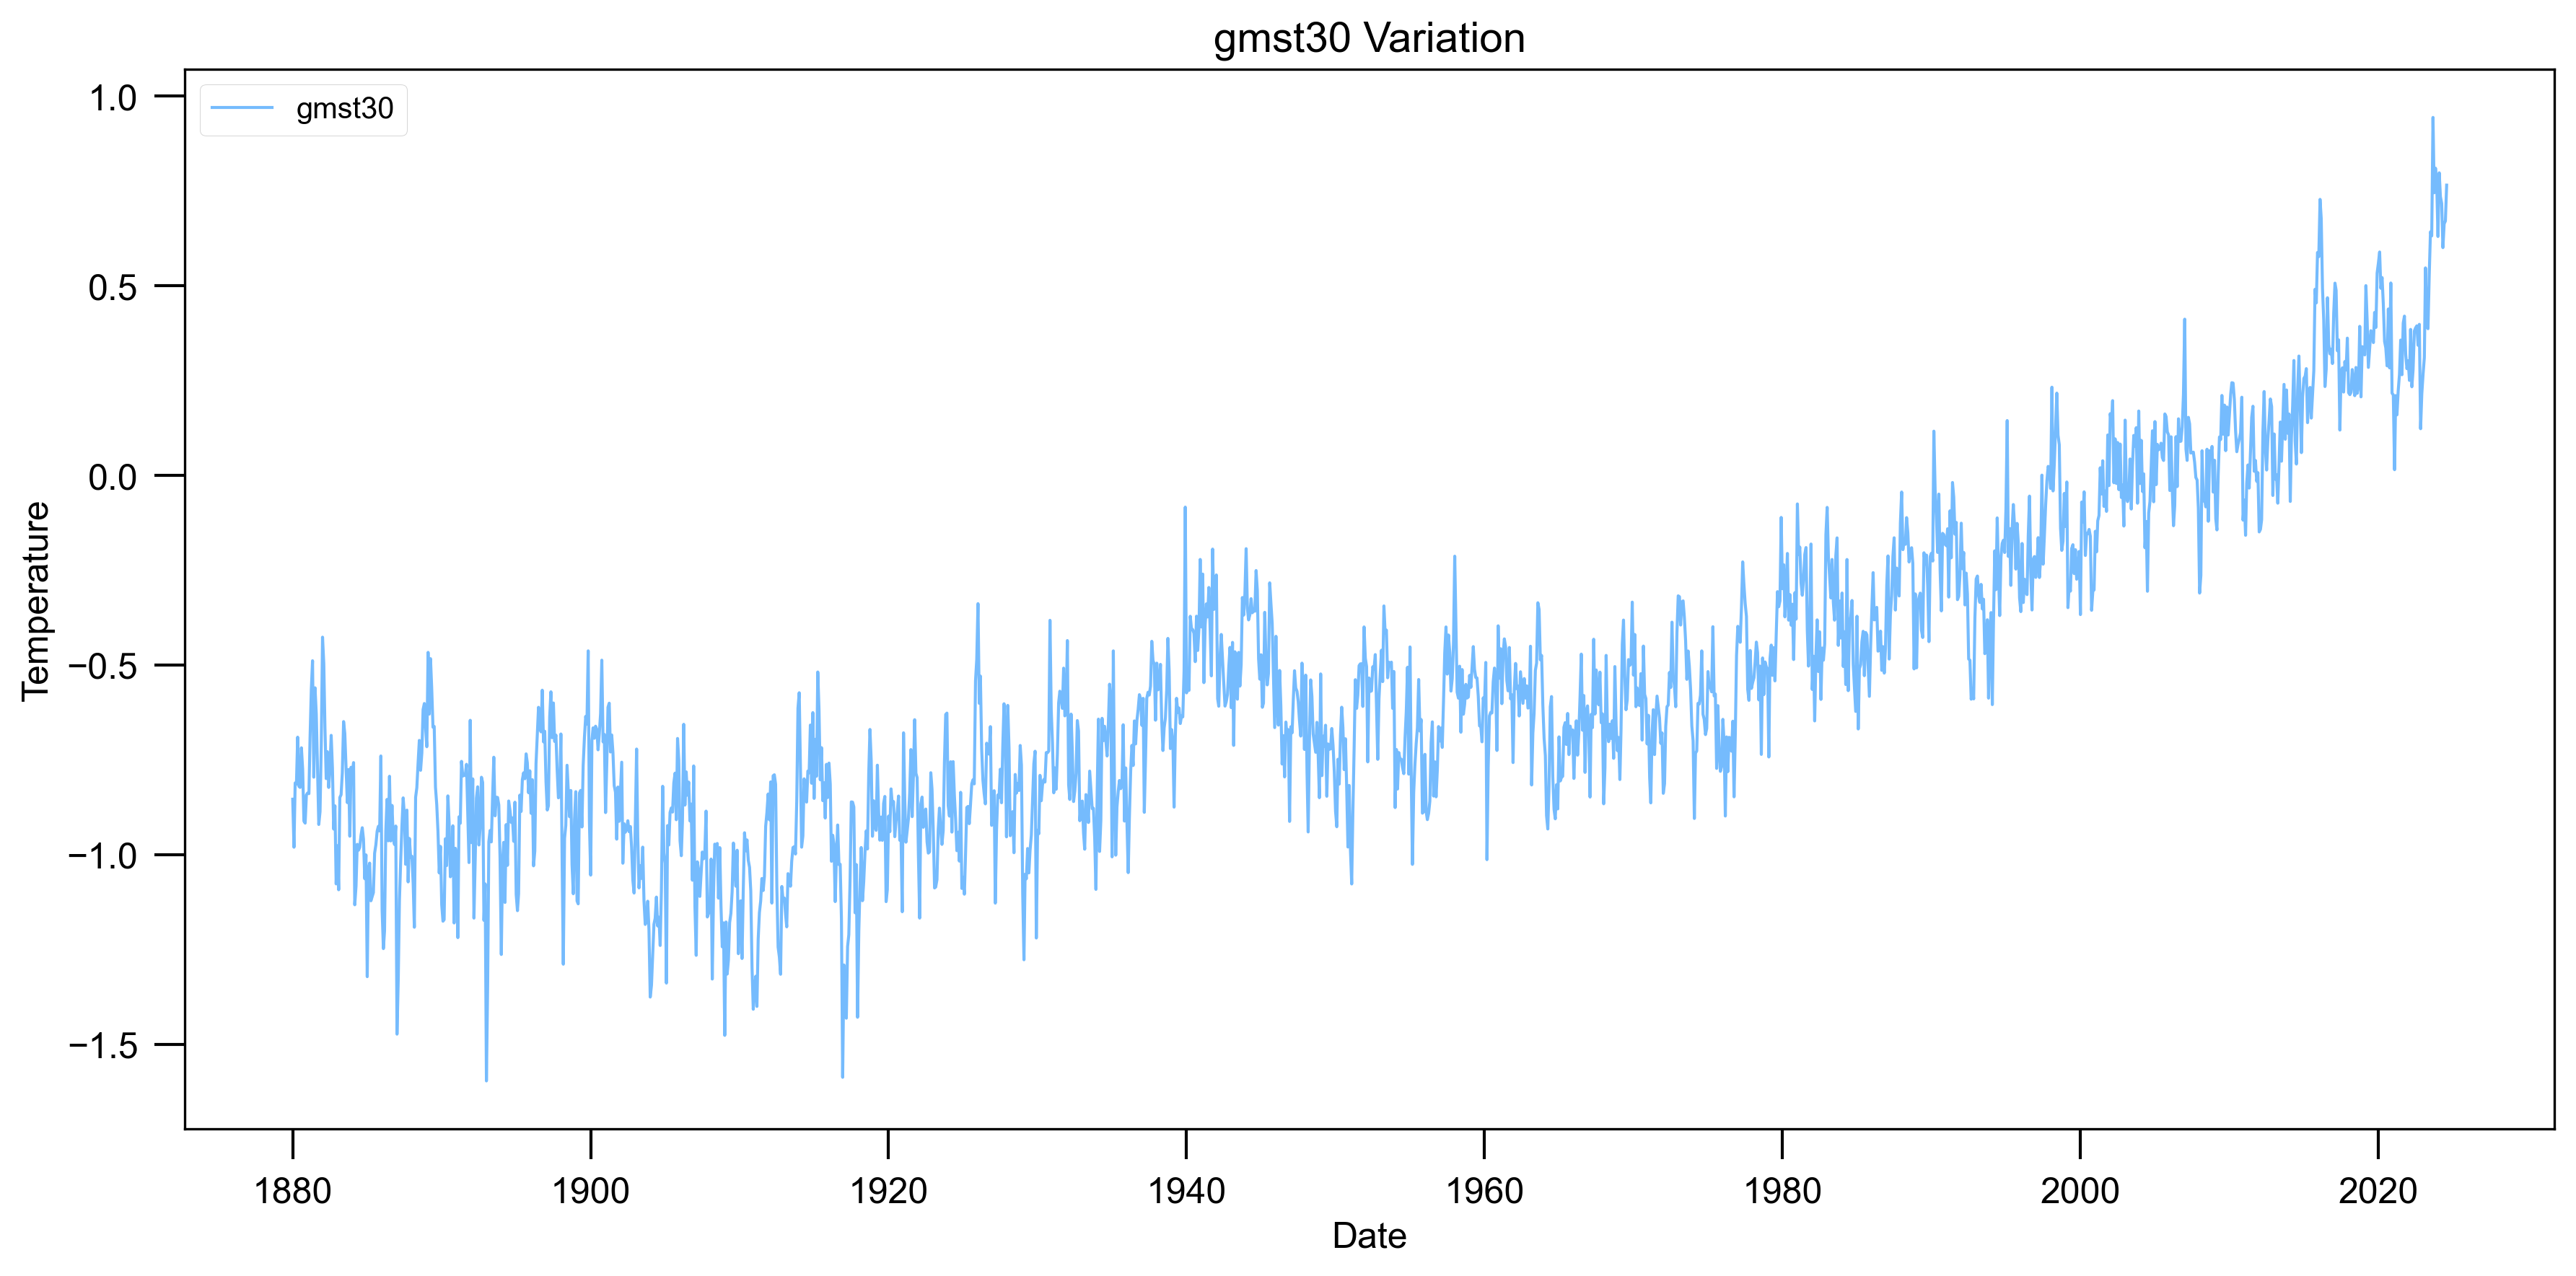

<Axes: title={'center': 'gmst30 Variation'}, xlabel='Date', ylabel='Temperature'>

In [23]:
plotgmst(gmst30,gmst30,0)


In [24]:
def ddf(df):
    m = len(df)
    n = np.zeros([m-2,1])
    for i in range(1,m-2):
        n[i-1,0] = (-df.iloc[i,0]+df.iloc[i+2,0])/2
    daten = df.index[1:-1]
    s = pd.DataFrame(n,columns = ['dgmst'],index = daten)
    return s

In [25]:
dgmst30 = ddf(gmst30)
dgmst30

,dgmst
1880-02-01,0.083027
1880-03-01,0.060372
1880-04-01,-0.002811
1880-05-01,-0.066246
1880-06-01,0.050885
...,...
2024-03-01,-0.067295
2024-04-01,-0.026831
2024-05-01,0.035119
2024-06-01,0.050940


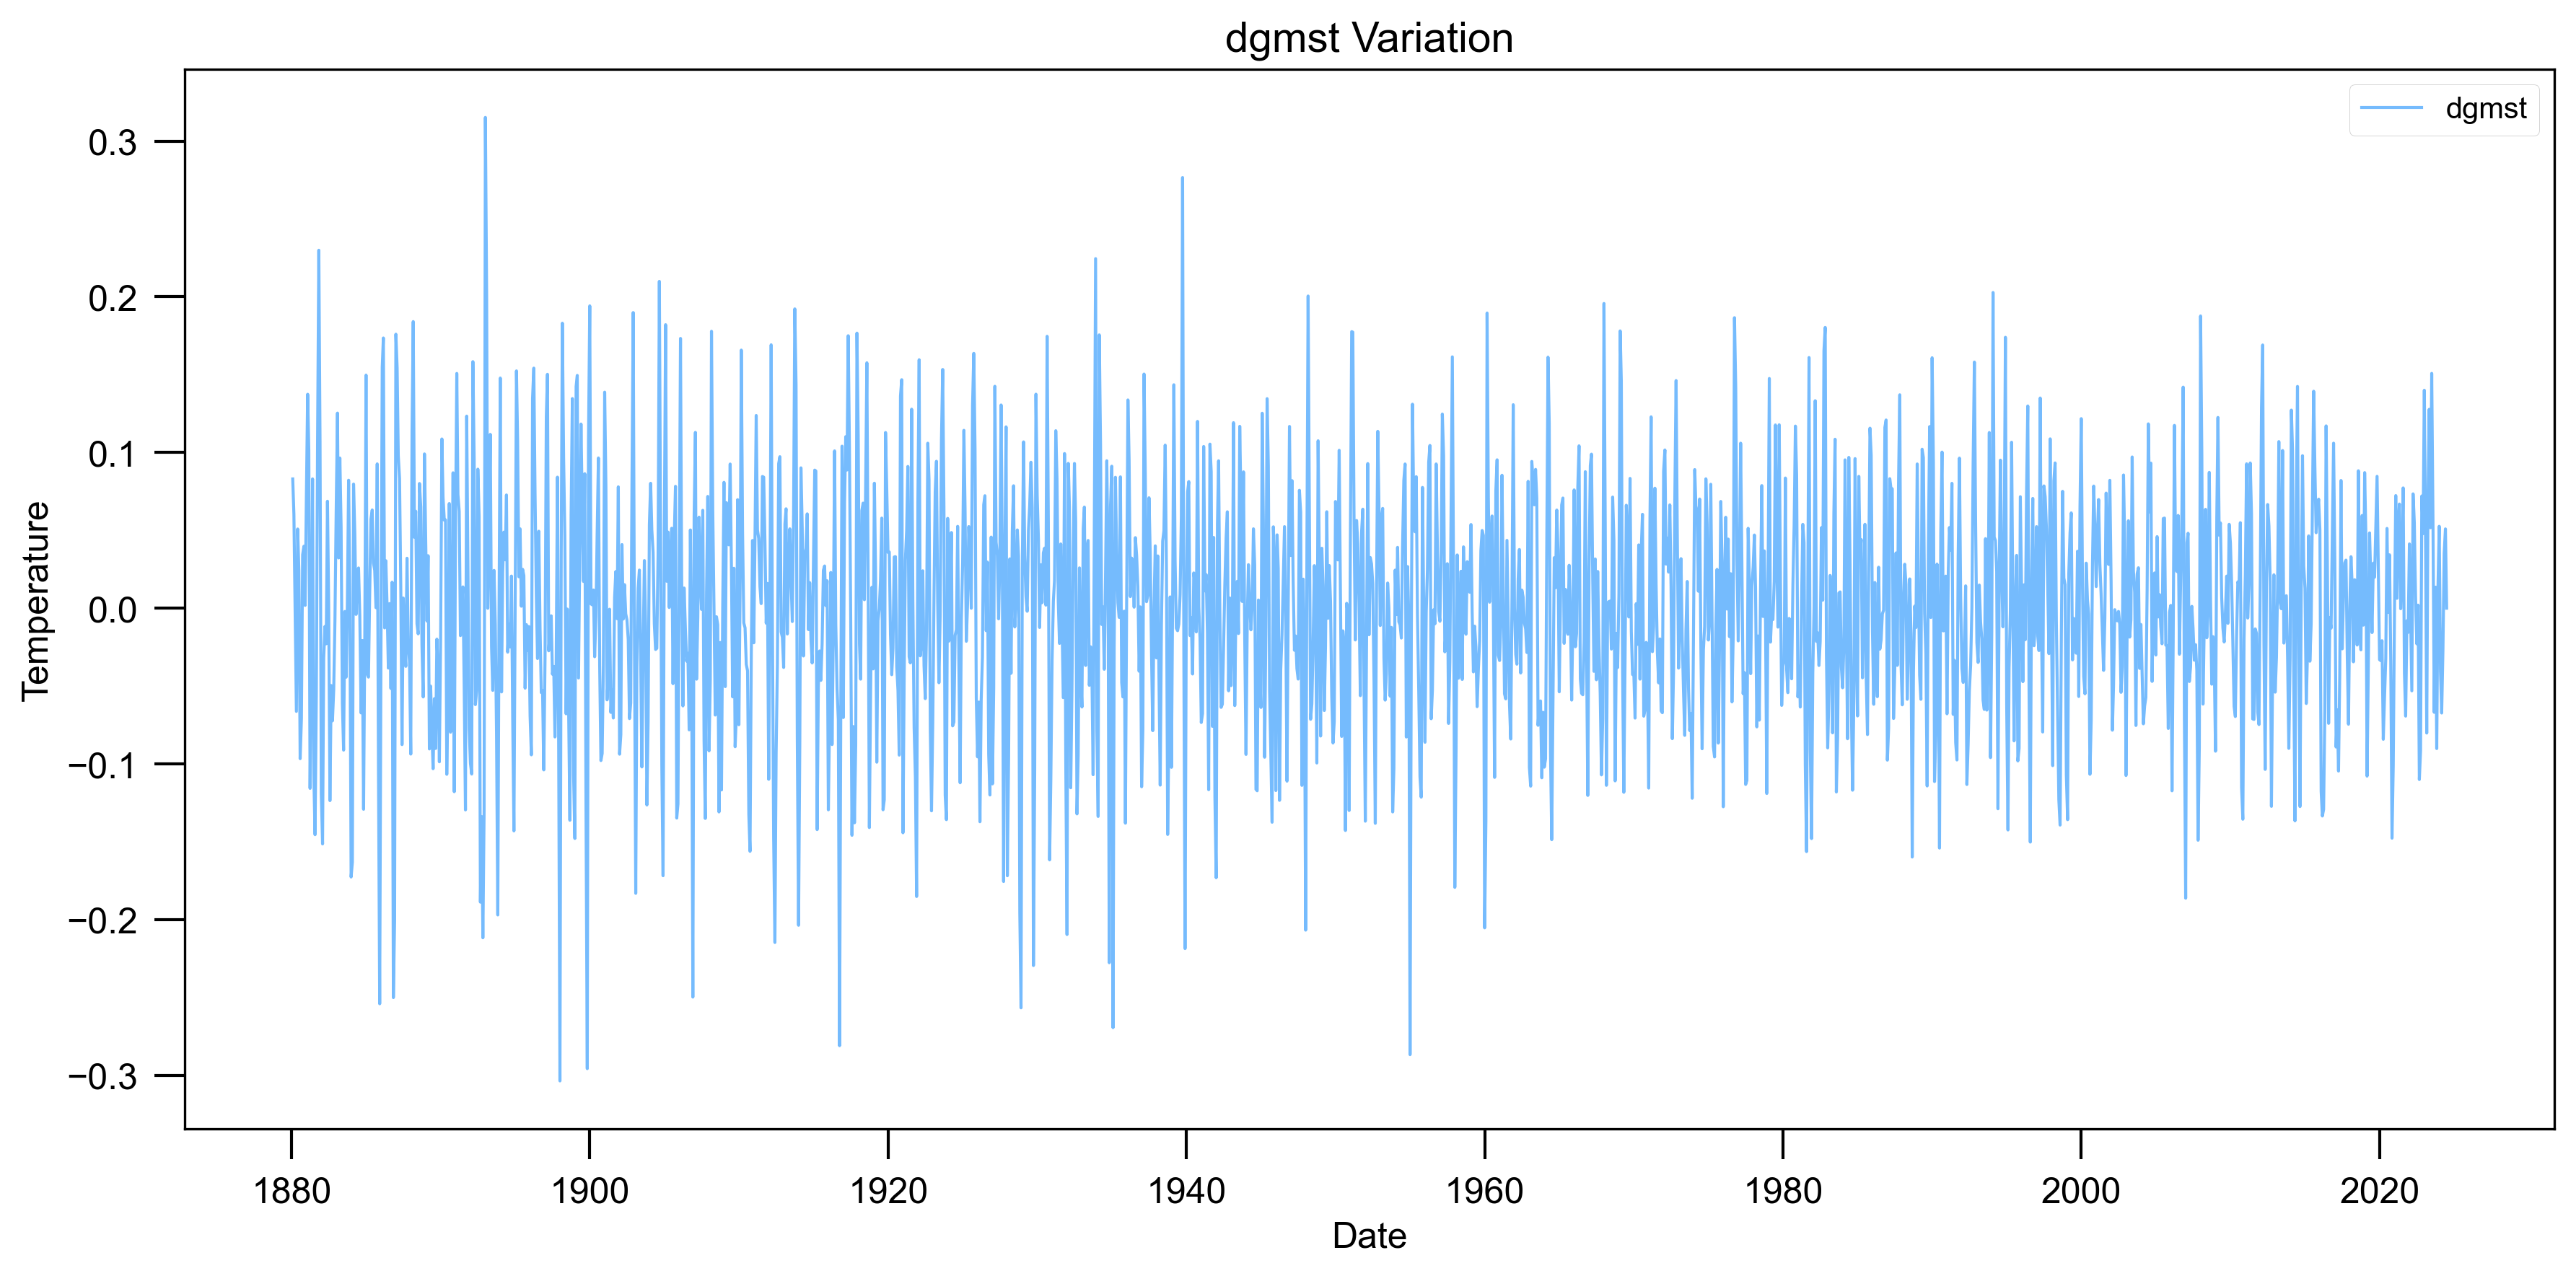

In [26]:
ax1 = plotgmst(dgmst30,dgmst30,0)

In [27]:
std = np.std(dgmst30)
std

E:\machinelearn\envs\svxc\lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


dgmst    0.077362
dtype: float64

In [28]:
def plotgmst_std(df,df2,n,std):
    # 创建figure和axes对象（面向对象风格）
    fig, ax = plt.subplots(figsize=(12, 6))  # 添加合理的画布尺寸
    
    # 绘制数据（明确指定label参数）
    ax.plot(df.index, df.iloc[:, 0], 
            linewidth=1, 
            color='#75bbfd',
            label=df.columns[0])  # 关键改进：使用label参数
    if(n):
        ax.scatter(df2.index,df2,s=40,  # 点大小优化：6-8pt直径
               color='#FF9933',  # 科技橙作为对比色
               edgecolor='w',  # 白色边缘增强辨识度
               linewidth=0.8,  # 边缘线宽
               alpha=0.9,  # 避免完全透明
               zorder=3,
               label='Significant Events')
    ax.axhline(std,c = 'r',lw = 3.0,ls = '-')
    # 设置刻度参数（正确作用于axes对象）
    ax.tick_params(
        which='major',
        width=1.0,
        labelsize=12,
        length=10
    )
    
    ax.legend(loc='best') 
    
    # 添加轴标签和标题（提升可读性）
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Temperature', fontsize=12)
    ax.set_title(f'{df.columns[0]} Variation', fontsize=14)
    
    plt.tight_layout() 
    plt.show()
    return (fig,ax)

## 1.99std

In [29]:
std_1_99 = 1.99*std.item()
(dgmst30>=std_1_99).any(axis = 1)

1880-02-01    False
1880-03-01    False
1880-04-01    False
1880-05-01    False
1880-06-01    False
              ...  
2024-03-01    False
2024-04-01    False
2024-05-01    False
2024-06-01    False
2024-07-01    False
Freq: MS, Length: 1734, dtype: bool

In [30]:

dgmst_idx1_99 = dgmst30.loc[(dgmst30>=std_1_99).any(axis = 1)]


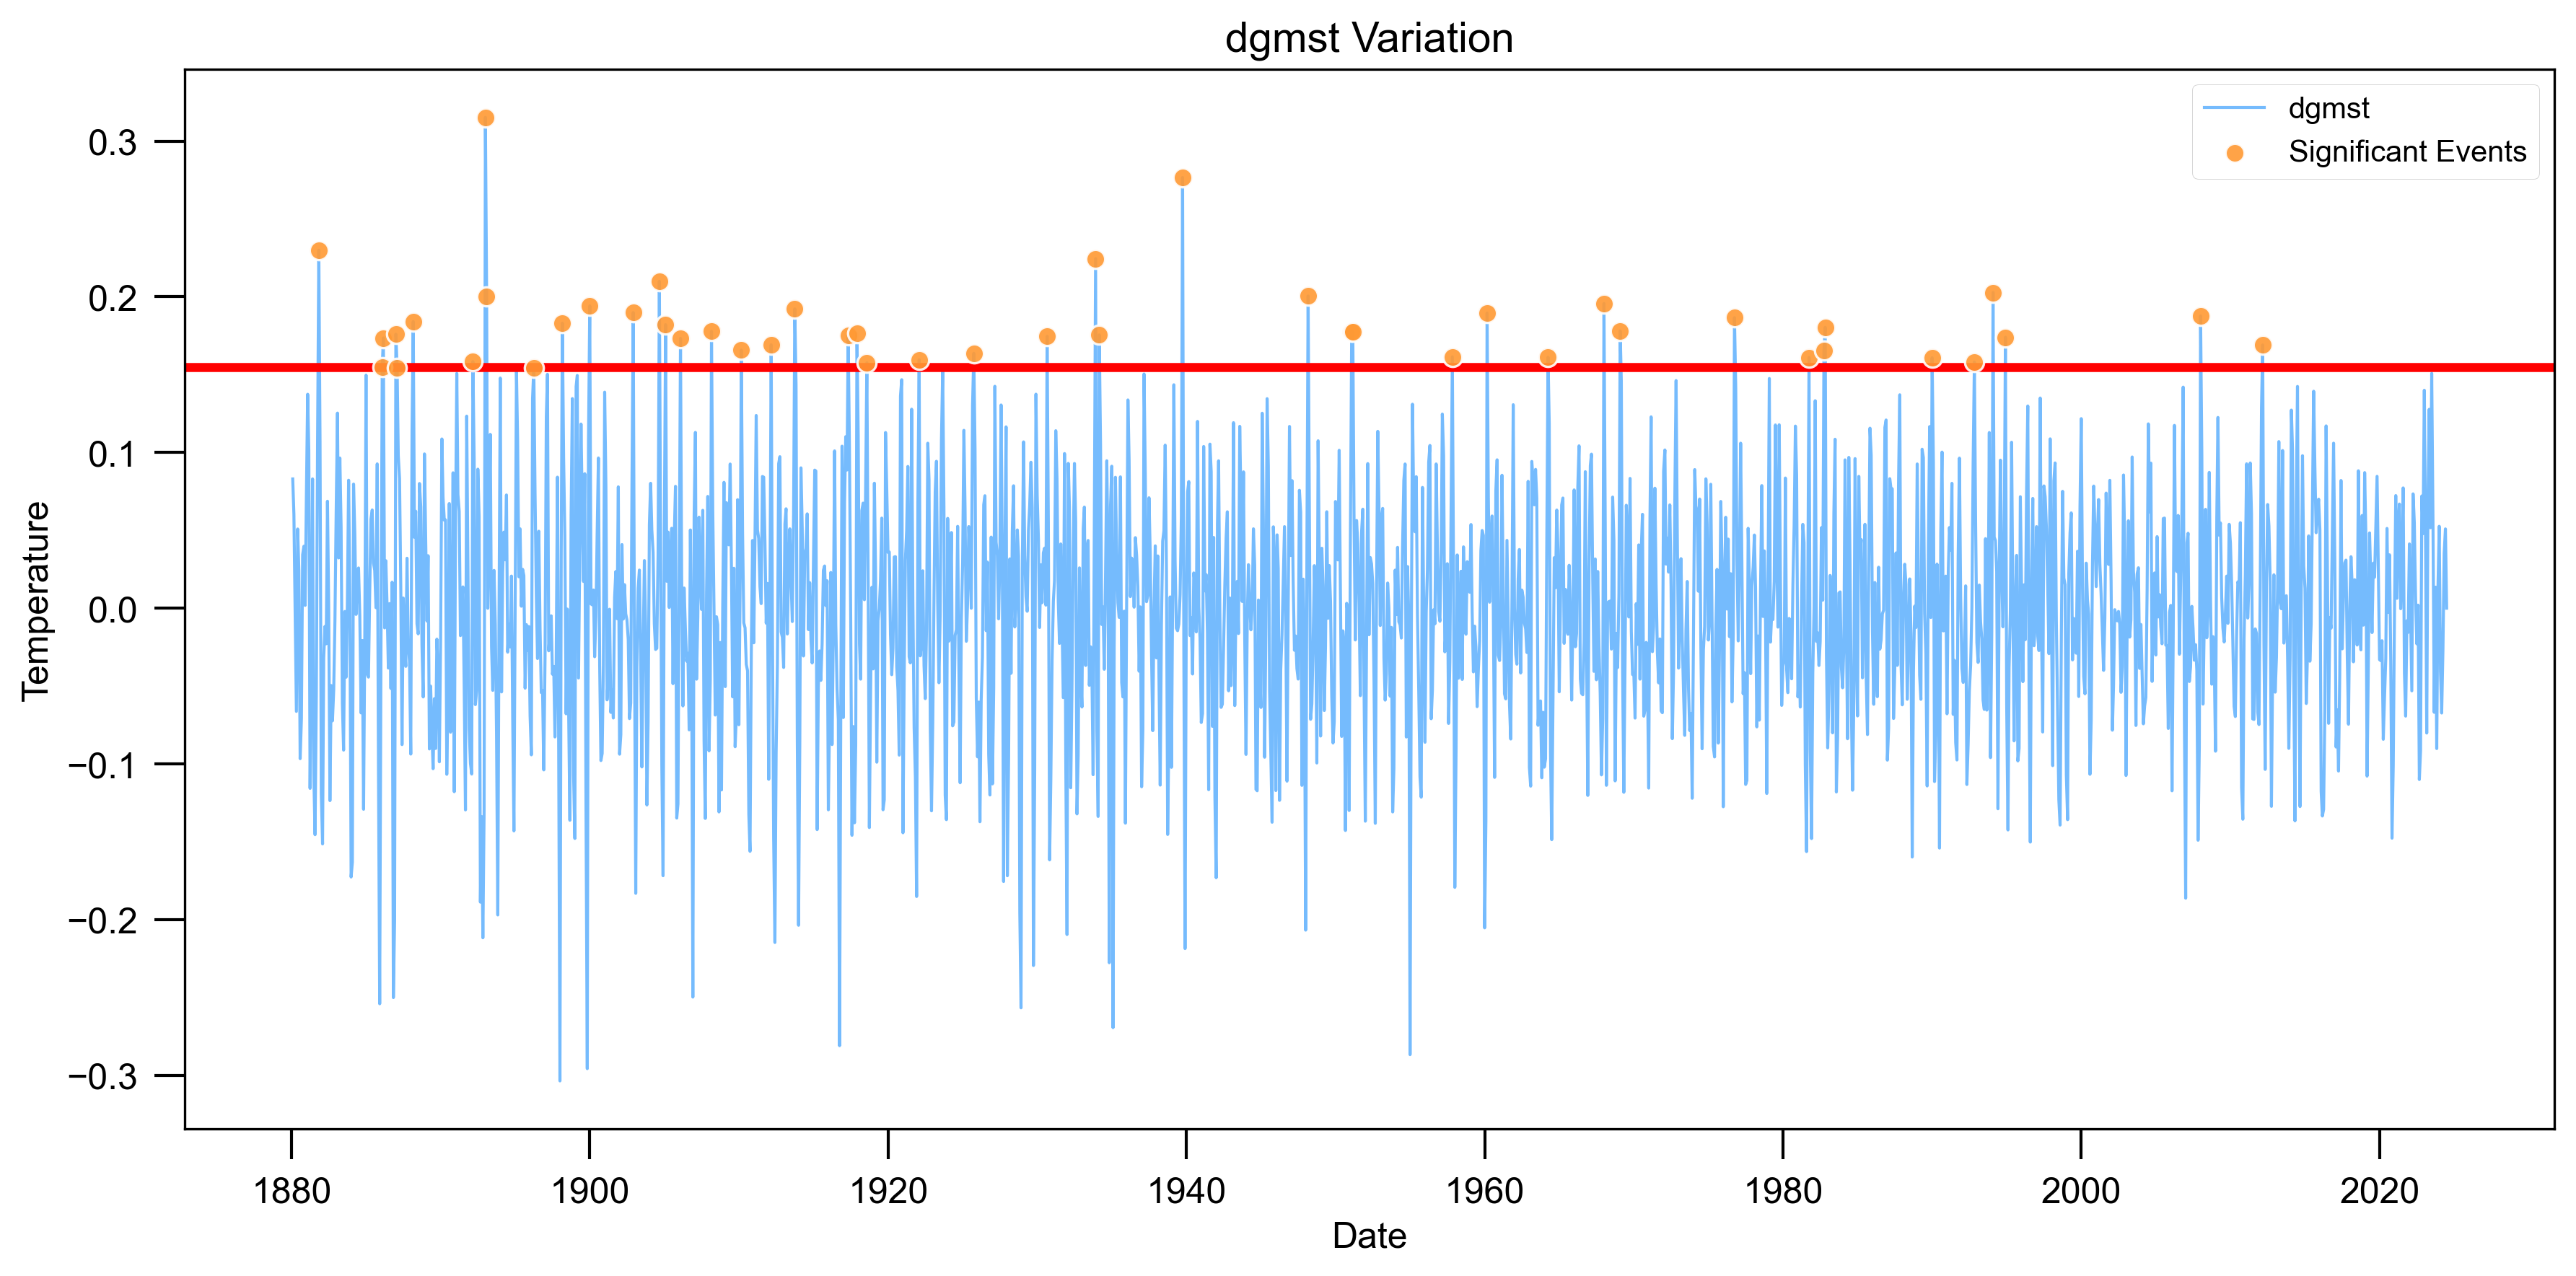

(<Figure size 3600x1800 with 1 Axes>,
 <Axes: title={'center': 'dgmst Variation'}, xlabel='Date', ylabel='Temperature'>)

In [31]:
std_1_99 = 2.0*std.item()
type(std_1_99)



plotgmst_std(dgmst30,dgmst_idx1_99,1,std_1_99)


In [38]:
_2std_gm_id =  gmst30.iloc[1:-1].loc[(dgmst30>=std_1_99).any(axis = 1)].index

In [40]:
_2std_gm_id_1 = _2std_gm_id-pd.DateOffset(months = 1)

In [42]:
_2std_gm_id_1

DatetimeIndex(['1881-10-01', '1886-01-01', '1886-02-01', '1886-12-01',
               '1888-02-01', '1892-02-01', '1892-12-01', '1893-01-01',
               '1898-02-01', '1899-12-01', '1902-11-01', '1904-08-01',
               '1905-01-01', '1906-01-01', '1908-02-01', '1910-02-01',
               '1912-02-01', '1913-09-01', '1917-04-01', '1917-11-01',
               '1918-07-01', '1922-01-01', '1925-09-01', '1930-08-01',
               '1933-11-01', '1934-02-01', '1939-09-01', '1948-02-01',
               '1951-01-01', '1951-02-01', '1957-10-01', '1960-02-01',
               '1964-03-01', '1967-12-01', '1969-01-01', '1976-09-01',
               '1981-09-01', '1982-09-01', '1982-10-01', '1989-12-01',
               '1992-10-01', '1994-01-01', '1994-11-01', '2007-12-01',
               '2012-02-01'],
              dtype='datetime64[ns]', freq=None)

In [44]:
_2std_gm_id

DatetimeIndex(['1881-11-01', '1886-02-01', '1886-03-01', '1887-01-01',
               '1888-03-01', '1892-03-01', '1893-01-01', '1893-02-01',
               '1898-03-01', '1900-01-01', '1902-12-01', '1904-09-01',
               '1905-02-01', '1906-02-01', '1908-03-01', '1910-03-01',
               '1912-03-01', '1913-10-01', '1917-05-01', '1917-12-01',
               '1918-08-01', '1922-02-01', '1925-10-01', '1930-09-01',
               '1933-12-01', '1934-03-01', '1939-10-01', '1948-03-01',
               '1951-02-01', '1951-03-01', '1957-11-01', '1960-03-01',
               '1964-04-01', '1968-01-01', '1969-02-01', '1976-10-01',
               '1981-10-01', '1982-10-01', '1982-11-01', '1990-01-01',
               '1992-11-01', '1994-02-01', '1994-12-01', '2008-01-01',
               '2012-03-01'],
              dtype='datetime64[ns]', freq=None)

In [46]:
_2std_gm_id_2 = _2std_gm_id+pd.DateOffset(months = 1)


In [32]:
# 拼接方法


In [36]:
std = np.std(dgmst30)
std_1_99 = 1.99*std.item()
(dgmst30>=std_1_99).any(axis = 1)
_2std_gm_id =  gmst30.iloc[1:-1].loc[(dgmst30>=std_1_99).any(axis = 1)].index #最初时间点
_2std_gm_id_1 = _2std_gm_id-pd.DateOffset(months = 1)#前一个月
_2std_gm_id_2 = _2std_gm_id+pd.DateOffset(months = 1)#后一个月
_2std_gm_id_3 = _2std_gm_id+4*pd.DateOffset(months = 1)#后三个月（第二种拼接使用）
a = gmst30.loc[_2std_gm_id_2].to_numpy() -gmst30.loc[_2std_gm_id_1].to_numpy()#在快速上升其及其以后的点都减去快速上升期与前一个云的
b =  gmst30.loc[_2std_gm_id_3].to_numpy() -gmst30.loc[_2std_gm_id_1].to_numpy()
gmst30_1 =gmst30.copy()
for date,k in zip(_2std_gm_id,a):
    gmst30_1[date:] = gmst30_1[date:] - k

E:\machinelearn\envs\svxc\lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


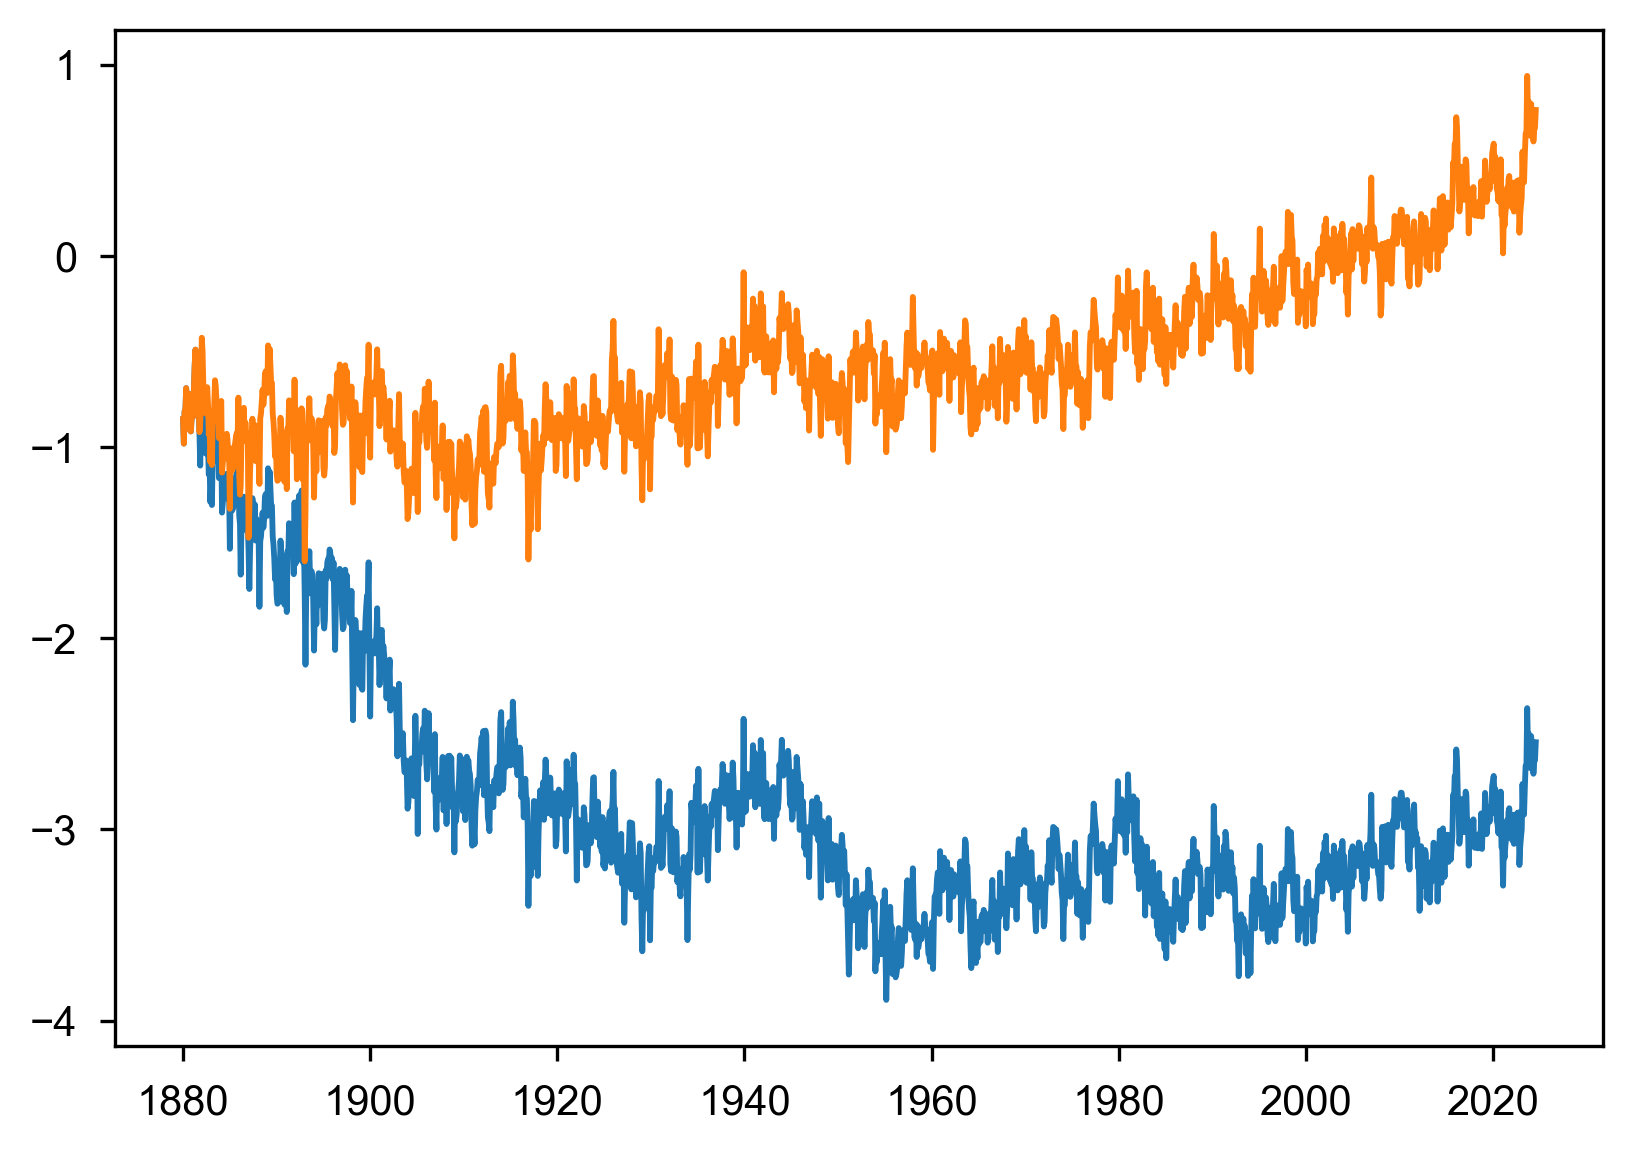

In [37]:
plt.figure()
plt.plot(gmst30_1.index,gmst30_1)
plt.plot(gmst30_1.index,gmst30)
plt.show()

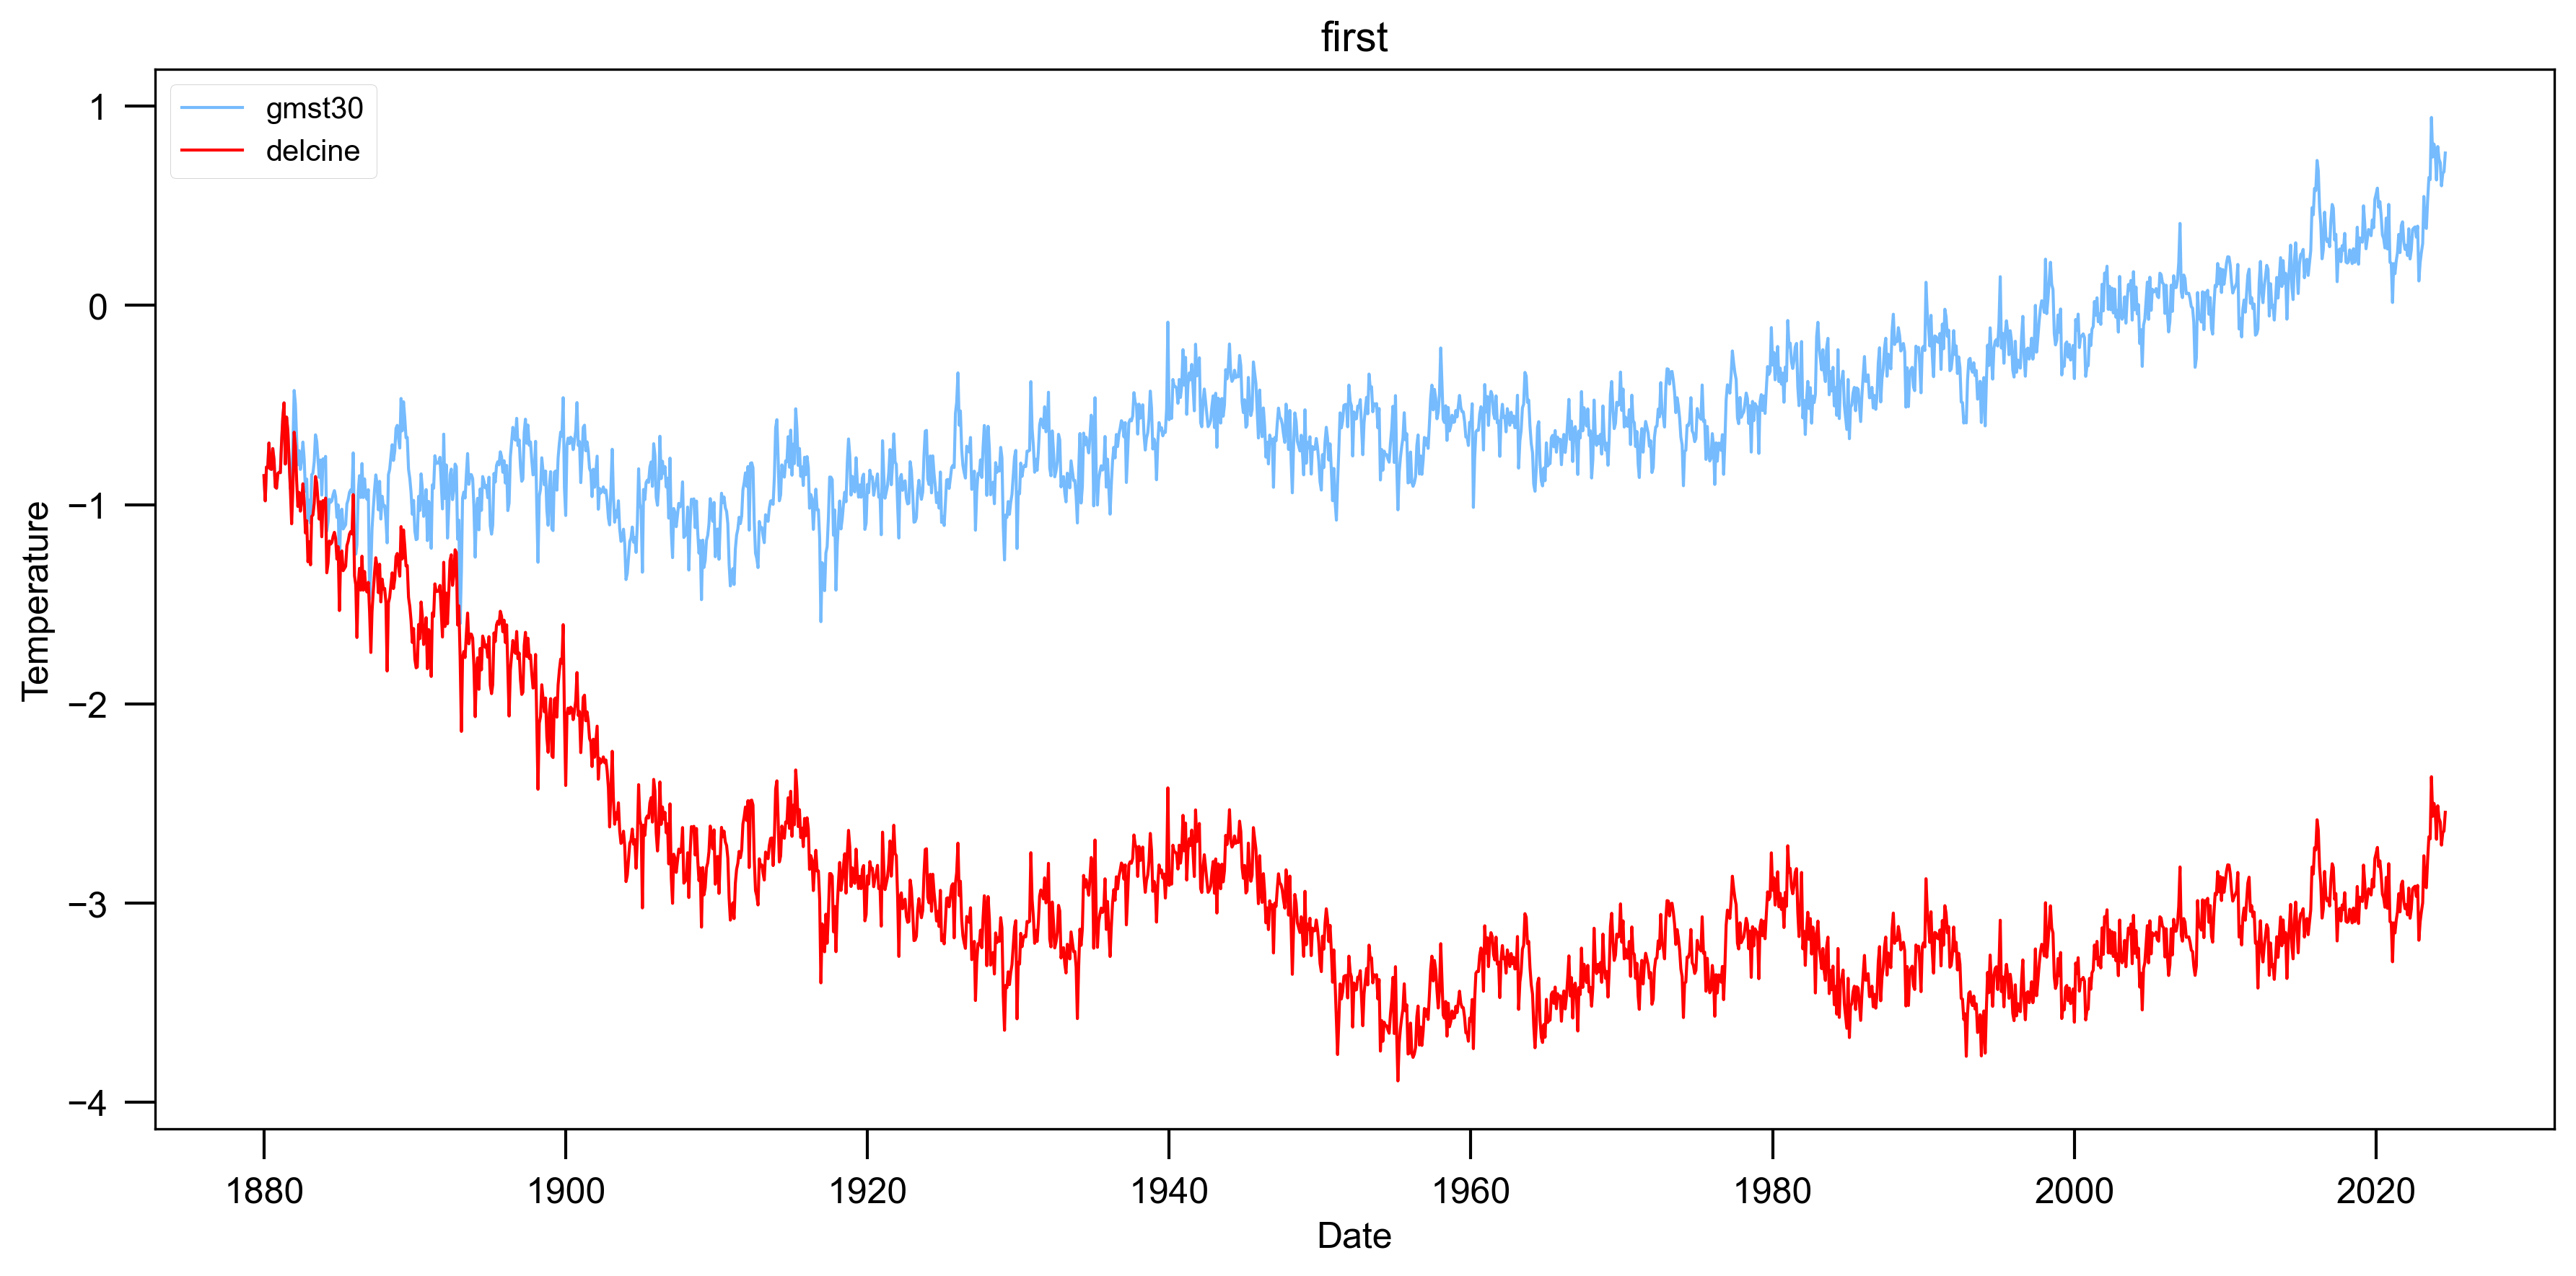

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))  # 添加合理的画布尺寸
    
# 绘制数据（明确指定label参数）
ax.plot(gmst30_1.index,gmst30, 
        linewidth=1, 
        color='#75bbfd',
        label=gmst30.columns[0])  # 关键改进：使用label参数

ax.plot(gmst30_1.index,gmst30_1,
        linewidth=1, 
        color='red',
        label='delcine')
# 设置刻度参数（正确作用于axes对象）
ax.tick_params(
    which='major',
    width=1.0,
    labelsize=12,
    length=10
)

ax.legend(loc='best') 

# 添加轴标签和标题（提升可读性）
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Temperature', fontsize=12)
ax.set_title('first', fontsize=14)

plt.tight_layout() 
plt.show()

# 第二种


In [41]:
std = np.std(dgmst30)
std_1_99 = 1.99*std.item()
(dgmst30>=std_1_99).any(axis = 1)
_2std_gm_id =  gmst30.iloc[1:-1].loc[(dgmst30>=std_1_99).any(axis = 1)].index #最初时间点
_2std_gm_id_1 = _2std_gm_id-pd.DateOffset(months = 1)#前一个月
_2std_gm_id_2 = _2std_gm_id+pd.DateOffset(months = 1)#后一个月
_2std_gm_id_3 = _2std_gm_id+3*pd.DateOffset(months = 1)#后三个月（第二种拼接使用）
a = gmst30.loc[_2std_gm_id_2].to_numpy() -gmst30.loc[_2std_gm_id_1].to_numpy()#在快速上升其及其以后的点都减去快速上升期与前一个云的
b =  gmst30.loc[_2std_gm_id_3].to_numpy() -gmst30.loc[_2std_gm_id_1].to_numpy()
gmst30_1 =gmst30.copy()
for date,k in zip(_2std_gm_id,a):
    gmst30_1[date:] = gmst30_1[date:] + k
gmst30_2 =gmst30.copy()
for date,k in zip(_2std_gm_id_2,b):
    gmst30_2[date:] = gmst30_2[date:] - k

E:\machinelearn\envs\svxc\lib\site-packages\numpy\core\fromnumeric.py:3643: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


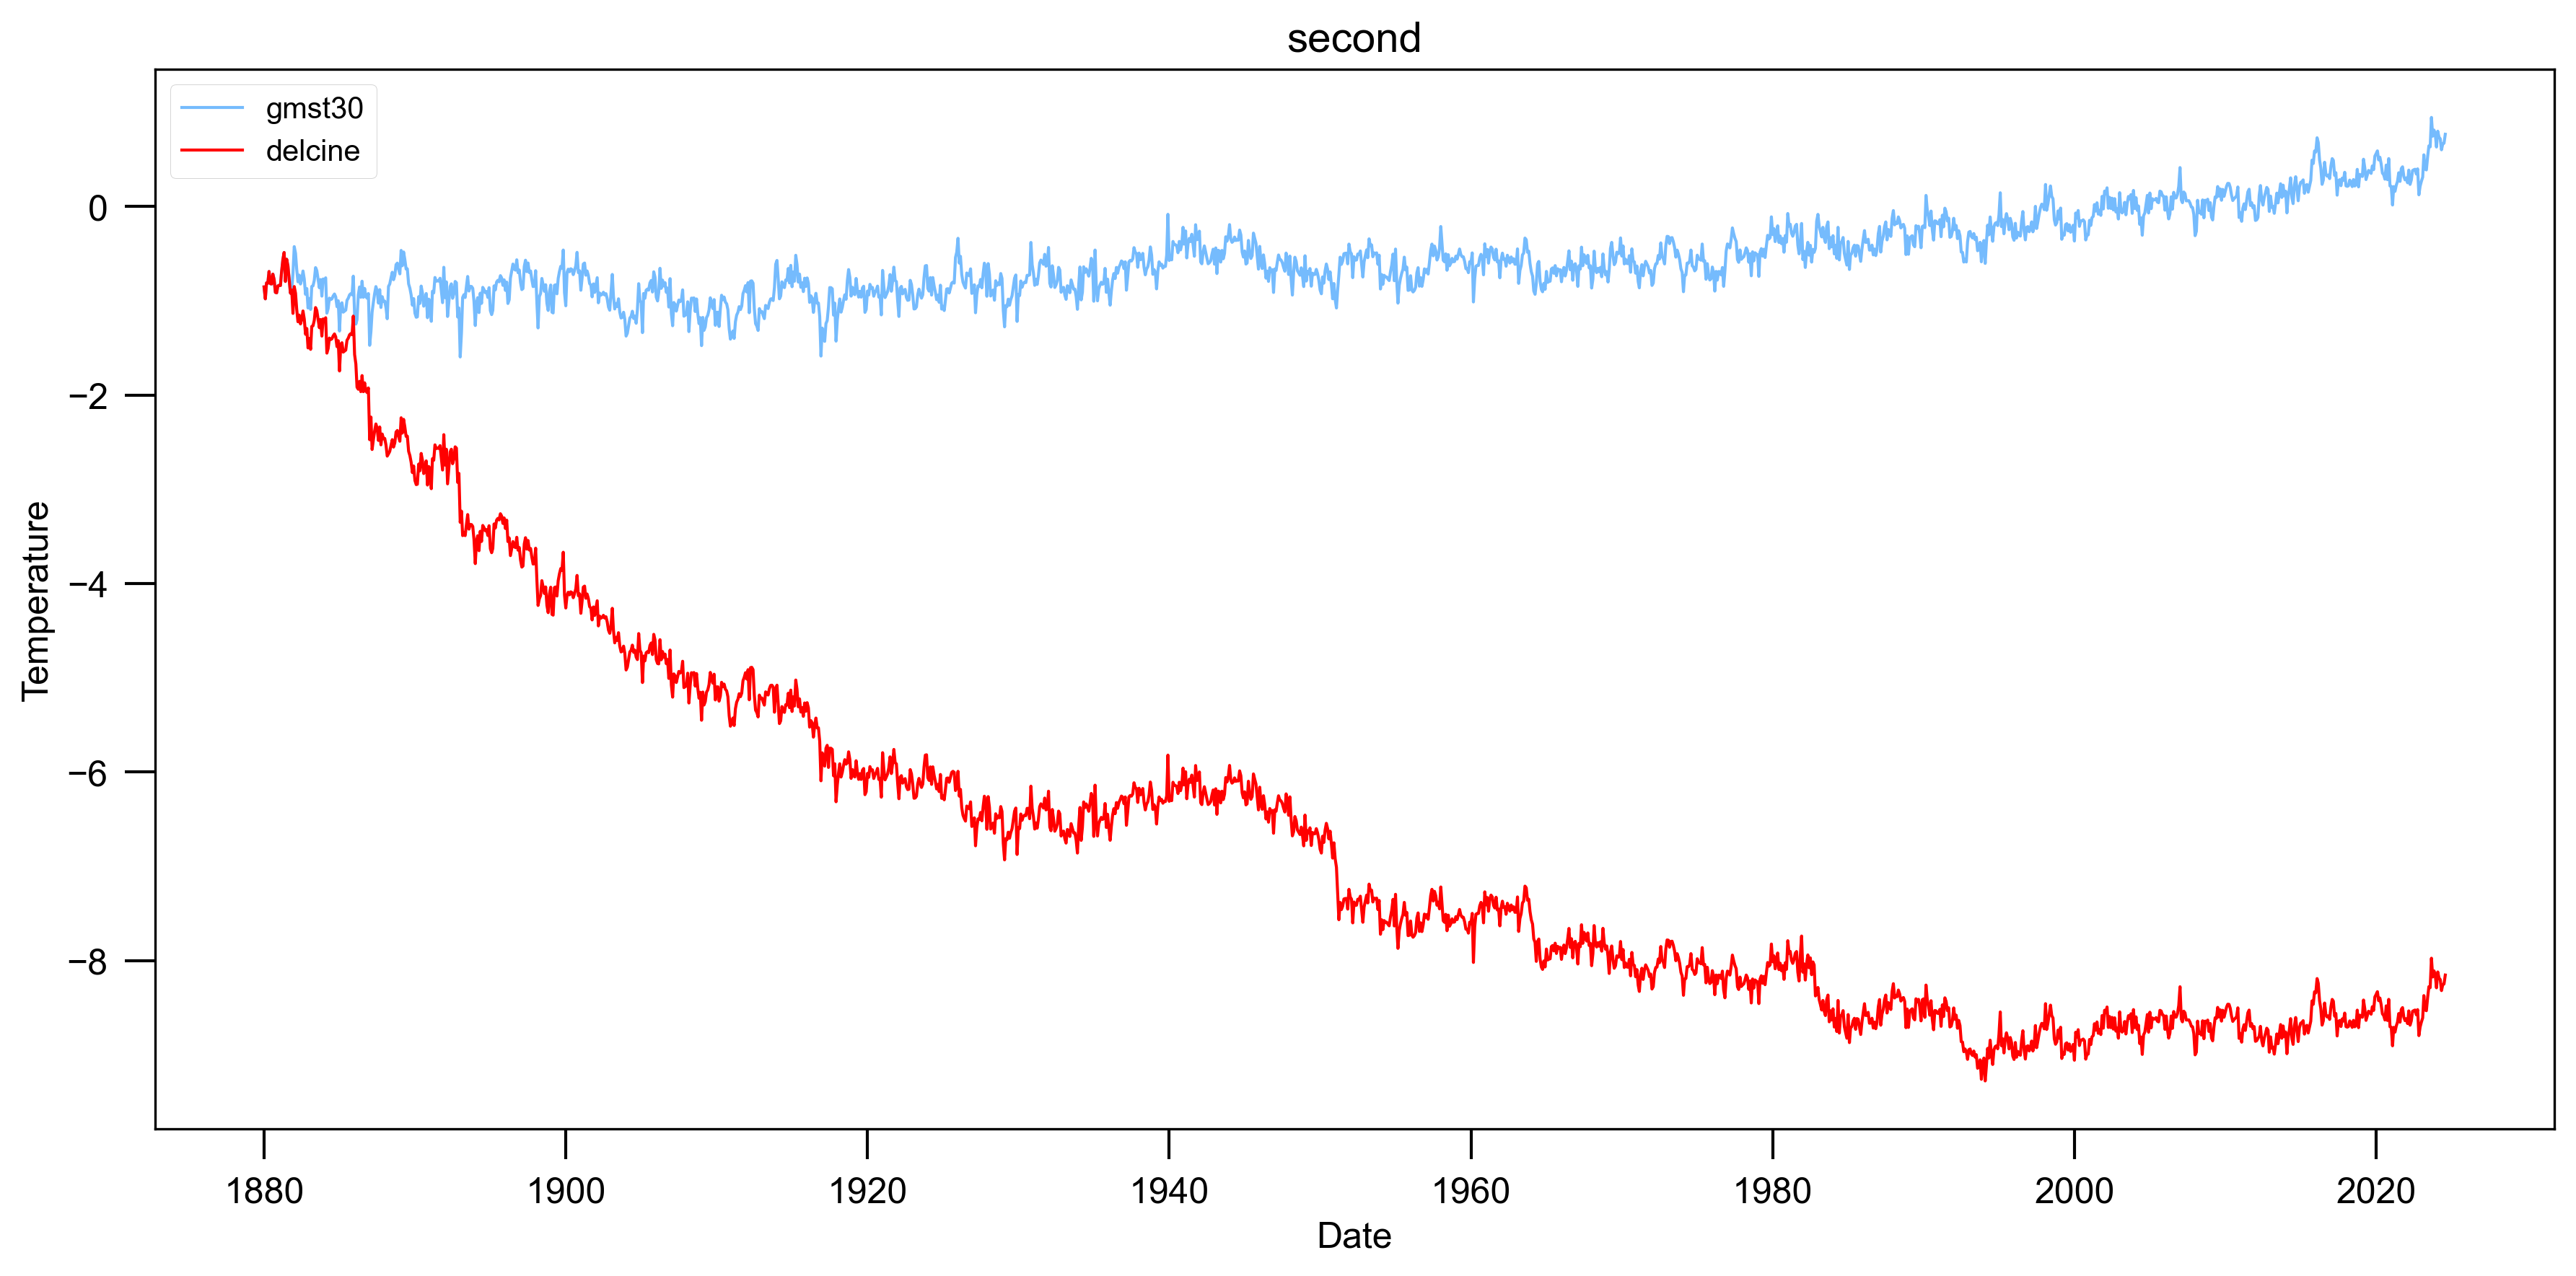

In [42]:
gmst30_2 =gmst30.copy()
for date,k in zip(_2std_gm_id_2,b):
    gmst30_2[date:] = gmst30_2[date:] - k
fig, ax = plt.subplots(figsize=(12, 6))  # 添加合理的画布尺寸
    
# 绘制数据（明确指定label参数）
ax.plot(gmst30_2.index,gmst30, 
        linewidth=1, 
        color='#75bbfd',
        label=gmst30.columns[0])  # 关键改进：使用label参数

ax.plot(gmst30_2.index,gmst30_2,
        linewidth=1, 
        color='red',
        label='delcine')
# 设置刻度参数（正确作用于axes对象）
ax.tick_params(
    which='major',
    width=1.0,
    labelsize=12,
    length=10
)

ax.legend(loc='best') 

# 添加轴标签和标题（提升可读性）
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Temperature', fontsize=12)
ax.set_title('second', fontsize=14)

plt.tight_layout() 
plt.show()

## 1.69STD


In [ ]:
std_1_99 = 1.69*std.item()
type(std_1_99)

dgmst_idx1_99 = dgmst30.loc[(dgmst30>=std_1_99).any(axis = 1)]

plotgmst_std(dgmst30,dgmst_idx1_99,1,std_1_99)

## 99PR

In [ ]:
std_1_99 = dgmst30.iloc[:,0].quantile(0.99).item()
type(std_1_99)

dgmst_idx1_99 = dgmst30.loc[(dgmst30>=std_1_99).any(axis = 1)]

plotgmst_std(dgmst30,dgmst_idx1_99,1,std_1_99)

## 以6月份为中心平均

In [17]:
gmst30.shape
gmst30_len = len(gmst30)
yearstar = np.arange(0,gmst30_len,12)
yearend = np.arange(11,gmst30_len,12)
slen = min(len(yearstar),len(yearend))
gmst_12 = np.zeros([slen,1])
mmm = 0;
for i, j in zip(yearstar[:slen],yearend[:slen]):
    gsum = 0
    for k in range(i,j+1):
        gsum+= gmst30.iloc[k,:]
    gmst_12[mmm,0] = gsum.item()/12
    mmm+=1
data12 = pd.date_range(start='1880/1/1',periods=slen,freq='YS')
gmst_12 = pd.DataFrame(gmst_12,index=data12)
plt.figure()
plt.title('gmst_6')
plt.plot(gmst_12)
plt.show()


NameError: name 'gmst30' is not defined

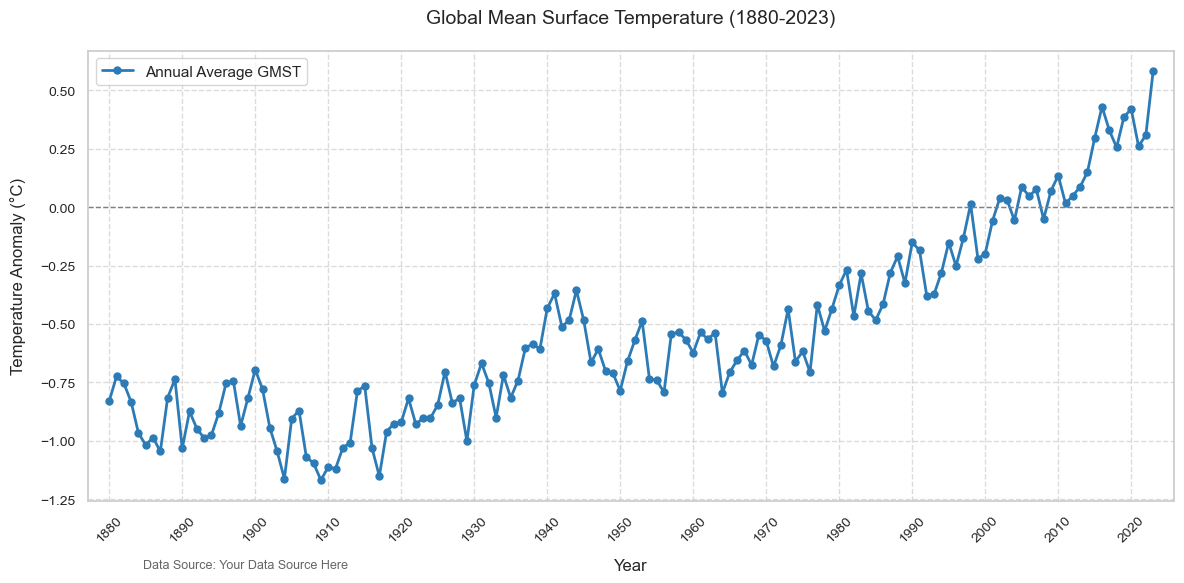

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import YearLocator, DateFormatter

# Set seaborn style
sns.set(style="whitegrid", palette="muted")

# Create figure with custom size
plt.figure(figsize=(12, 6))

# Plot data with enhanced styling
plt.plot(gmst_12.index, gmst_12.values, 
         color='#2c7bb6', linewidth=2, marker='o', markersize=5,
         label='Annual Average GMST')

# Format date axis
ax = plt.gca()
ax.xaxis.set_major_locator(YearLocator(10))  # Show year every 10 years
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.xticks(rotation=45)

# Add labels and title
plt.title('Global Mean Surface Temperature (1880-{})'.format(gmst_12.index[-1].year), 
          fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Temperature Anomaly (°C)', fontsize=12, labelpad=10)

# Add grid and legend
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(frameon=True, facecolor='white')

# Add proper margins
plt.margins(x=0.02)

# Customize tick parameters
ax.tick_params(axis='both', which='major', labelsize=10)

# Add a zero reference line
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Add data source annotation
plt.text(0.05, -0.15, 'Data Source: Your Data Source Here', 
         transform=ax.transAxes, fontsize=9, color='#666666')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

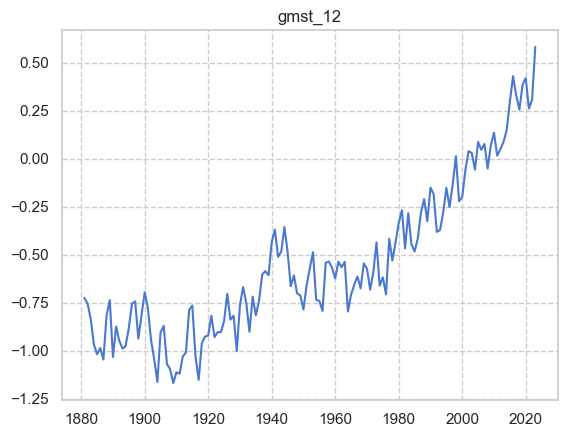

In [77]:
gmst30_1 = gmst30.copy().iloc[5:,:]
gmst30_1_len = len(gmst30_1)
yearstar = np.arange(0,gmst30_len,12)
yearend = np.arange(11,gmst30_len,12)
slen = min(len(yearstar),len(yearend))
gmst_12_2 = np.zeros([slen,1])
mmm = 0;
for i, j in zip(yearstar[:slen],yearend[:slen]):
    gsum = 0
    for k in range(i,j+1):
        gsum+= gmst30.iloc[k,:]
    gmst_12_2[mmm,0] = gsum.item()/12
    mmm+=1
data12 = pd.date_range(start='1881/1/1',periods=slen,freq='YS')
gmst_12_2 = pd.DataFrame(gmst_12,index=data12)
plt.figure()
plt.title('gmst_12')
plt.plot(gmst_12_2)
plt.show()
gmst_12_2.to_csv("avarangeof12.csv")

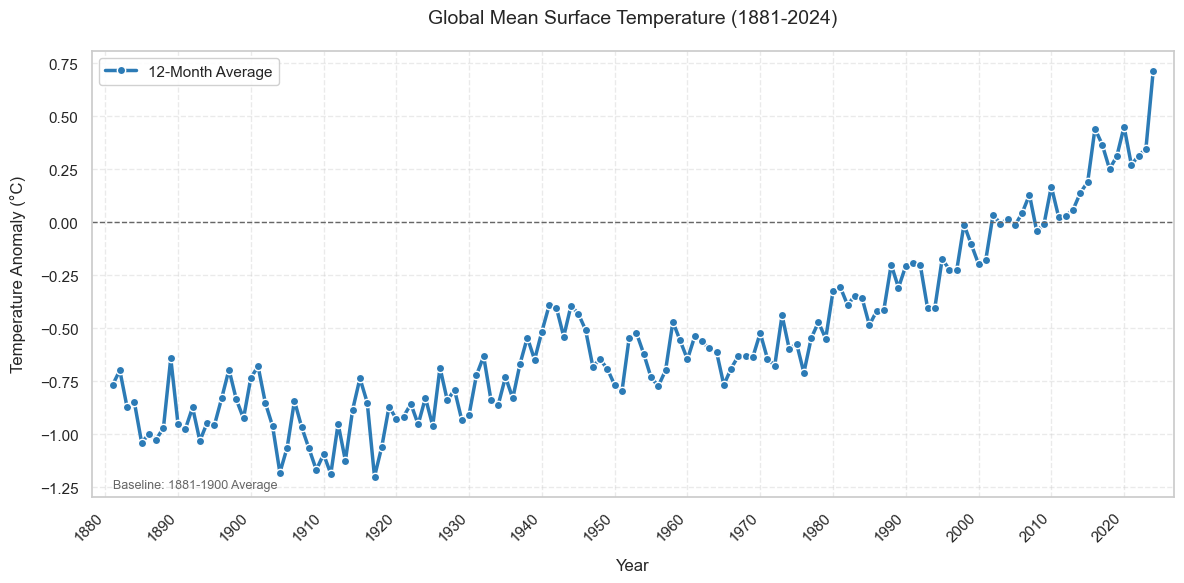

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import YearLocator, DateFormatter

# 数据预处理部分修正
gmst30_1 = gmst30.copy().iloc[5:,:]  # 从第6个月开始（假设每月1行）
gmst30_1_len = len(gmst30_1)

# 修正索引计算（使用新数据长度）
yearstar = np.arange(0, gmst30_1_len, 12)  # 使用截断后的数据长度
yearend = np.arange(11, gmst30_1_len, 12)
slen = min(len(yearstar), len(yearend))

# 初始化结果数组
gmst_12_2 = np.zeros([slen, 1])

# 数据聚合逻辑修正
mmm = 0
for i, j in zip(yearstar[:slen], yearend[:slen]):
    gsum = 0
    # 使用截断后的数据集 gmst30_1
    for k in range(i, min(j+1, gmst30_1_len)):  # 添加边界保护
        gsum += gmst30_1.iloc[k, 0]  # 假设温度数据在第0列
    gmst_12_2[mmm, 0] = gsum / 12
    mmm += 1

# 生成正确的时间索引（从1881年开始）
data12 = pd.date_range(start='1881-01-01', periods=slen, freq='YS')  # 修正日期格式
gmst_12 = pd.DataFrame(gmst_12_2, index=data12, columns=['Temperature'])

# 可视化美化
sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.6})
plt.figure(figsize=(12, 6))

# 带置信区间的平滑曲线（假设有标准差列可添加）
plt.plot(gmst_12.index, gmst_12['Temperature'], 
         color='#2c7bb6', linewidth=2.5, 
         marker='o', markersize=6, markeredgecolor='w',
         label='12-Month Average')

# 专业级图表元素
plt.title(f'Global Mean Surface Temperature ({data12[0].year}-{data12[-1].year})', 
         fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12, labelpad=10)
plt.ylabel('Temperature Anomaly (°C)', fontsize=12, labelpad=10)

# 高级日期格式
ax = plt.gca()
ax.xaxis.set_major_locator(YearLocator(10))  # 每10年一个主刻度
ax.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.xticks(rotation=45, ha='right')

# 参考线和注释
plt.axhline(0, color='#666666', linestyle='--', linewidth=1)
plt.text(0.02, 0.02, 'Baseline: 1881-1900 Average', 
         transform=ax.transAxes, color='#666666', fontsize=9)

# 图例和网格优化
plt.legend(loc='upper left', frameon=True, framealpha=0.9)
plt.grid(True, which='both', linestyle='--', alpha=0.4)

# 边距调整
plt.margins(x=0.02)
plt.tight_layout()

# 保存高质量图片
plt.savefig('GMST_12mo_Anomaly.png', dpi=300, bbox_inches='tight')
plt.show()

In [49]:
def ddf(df):
    m = len(df)
    n = np.zeros([m-2,1])
    for i in range(1,m-2):
        n[i-1,0] = (-df.iloc[i,0]+df.iloc[i+2,0])/2
    daten = df.index[1:-1]
    s = pd.DataFrame(n,columns = ['dgmst'],index = daten)
    return s

In [51]:
dgmst_6 = ddf(gmst_12)
dgmst_12 = ddf(gmst_12_2)

In [53]:
dgmst_6

,dgmst
1881-01-01,-0.054494
1882-01-01,-0.106334
1883-01-01,-0.092454
1884-01-01,-0.009686
1885-01-01,-0.013719
...,...
2018-01-01,0.082301
2019-01-01,-0.062468
2020-01-01,-0.056117
2021-01-01,0.160455


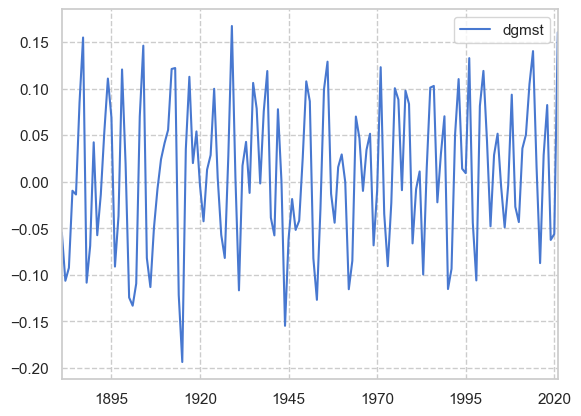

In [55]:
dgmst_6= dgmst_6.iloc[:-1,:]
dgmst_12= dgmst_12.iloc[:-1,:]
dgmst_6.plot()
plt.show()

In [67]:
std_12 = 1.69*np.std(dgmst_12.values).item()
std_6 = 1.69*np.std(dgmst_6.values).item()

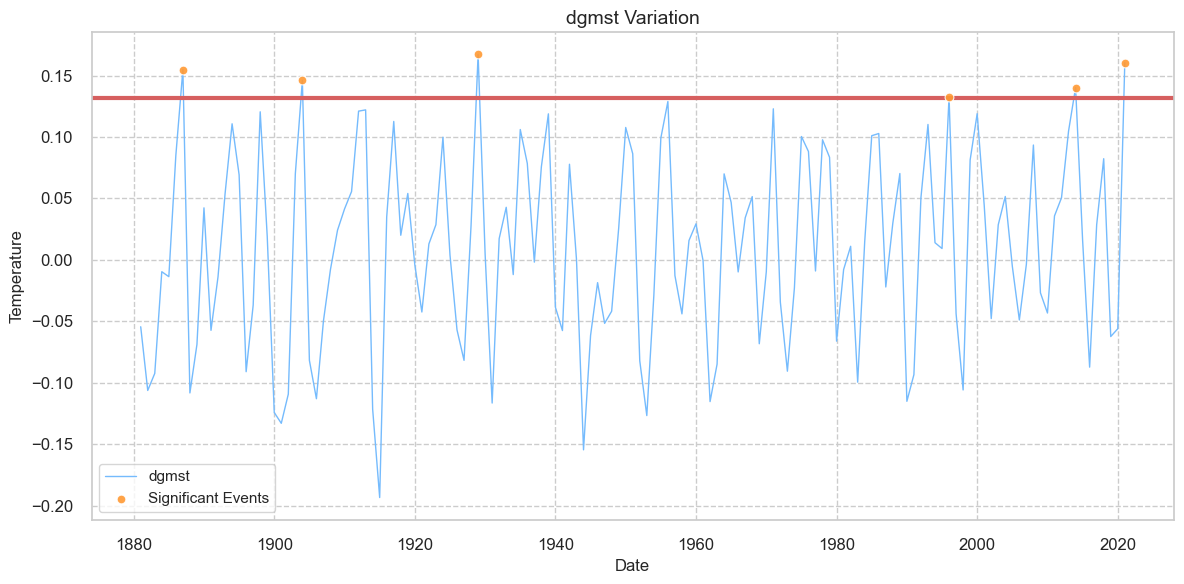

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'dgmst Variation'}, xlabel='Date', ylabel='Temperature'>)

In [69]:

dgmst_6_idx1_6 = dgmst_6.loc[(dgmst_6>=std_6).any(axis = 1)]

plotgmst_std(dgmst_6,dgmst_6_idx1_6,1,std_6)

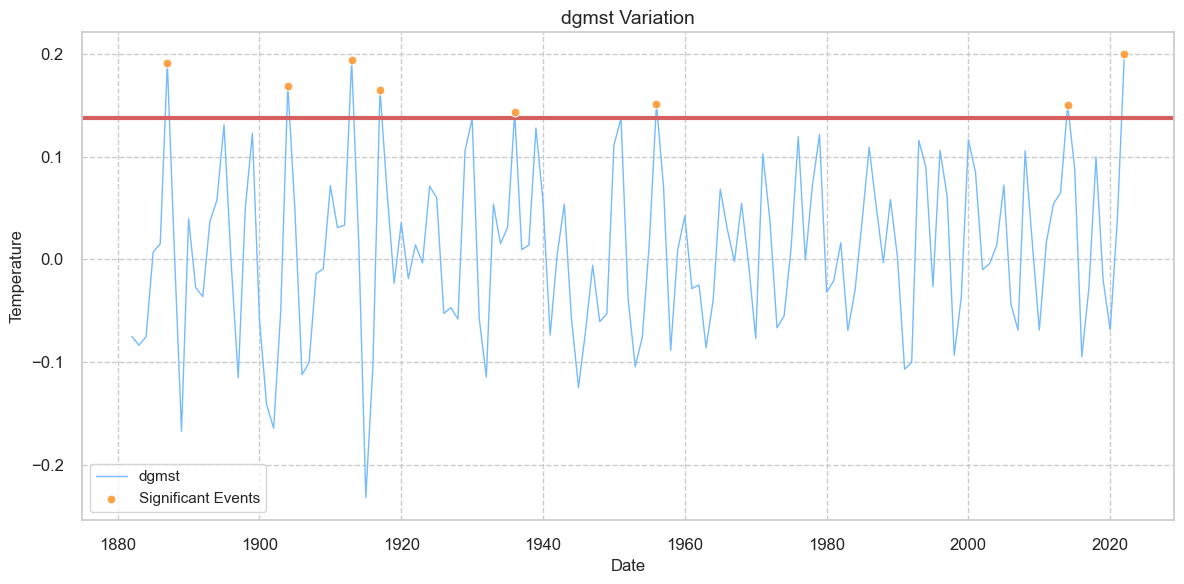

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'dgmst Variation'}, xlabel='Date', ylabel='Temperature'>)

In [70]:

dgmst_12_idx1_12 = dgmst_12.loc[(dgmst_12>=std_12).any(axis = 1)]

plotgmst_std(dgmst_12,dgmst_12_idx1_12,1,std_12)

# 两种图


In [ ]:
data_12_2 = gmst_12_2.iloc[1:-3].loc[(dgmst_12>=std_12).any(axis = 1)].index
data_6_6 = gmst_12.iloc[1:-2].loc[(dgmst_6>=std_6).any(axis = 1)].index

In [ ]:
_2std_gm_id = data_6_6.copy()
gmst306 = gmst_12.copy()
_2std_gm_id_1 = _2std_gm_id-pd.DateOffset(years = 1)#前一个月
_2std_gm_id_2 = _2std_gm_id+pd.DateOffset(years = 1)#后一个月
a = gmst306.loc[_2std_gm_id].to_numpy() -gmst306.loc[_2std_gm_id_1].to_numpy()#在快速上升其及其以后的点都减去快速上升期与前一个云的
b =  gmst306.loc[_2std_gm_id_2].to_numpy() -gmst306.loc[_2std_gm_id_1].to_numpy()
gmst306_1 =gmst306.copy()
for date,k in zip(_2std_gm_id,a):
    gmst306_1[date:] = gmst306_1[date:] + k
gmst306_2 =gmst306.copy()
for date,k in zip(_2std_gm_id_2,b):
    gmst306_2[date:] = gmst306_2[date:] - k

In [ ]:
_2std_gm_id = data_12_2.copy()
gmst3012 = gmst_12_2.copy()
_2std_gm_id_1 = _2std_gm_id-pd.DateOffset(years = 1)#前一个月
_2std_gm_id_2 = _2std_gm_id+pd.DateOffset(years = 1)#后一个月
a = gmst3012.loc[_2std_gm_id].to_numpy() -gmst3012.loc[_2std_gm_id_1].to_numpy()#在快速上升其及其以后的点都减去快速上升期与前一个云的
b =  gmst3012.loc[_2std_gm_id_2].to_numpy() -gmst3012.loc[_2std_gm_id_1].to_numpy()
gmst3012_1 =gmst3012.copy()
for date,k in zip(_2std_gm_id,a):
    gmst3012_1[date:] = gmst3012_1[date:] + k
gmst3012_2 =gmst3012.copy()
for date,k in zip(_2std_gm_id_2,b):
    gmst3012_2[date:] = gmst3012_2[date:] - k

In [ ]:
fig,axes = plt.subplots(4,1,figsize = (16,9))
tu = [gmst306_1,gmst306_2,gmst3012_1,gmst3012_2]
k = 0
for i,ax in zip(tu,axes):
    ax.plot(i.index,i,label=f'第{k%2+1}种',lw = 2.0)
    k+=k
    plt.legend()

plt.show()

In [ ]:
import matplotlib.pyplot as plt

# 设置全局样式
plt.style.use('seaborn-v0_8')  # 使用 seaborn 主题（更美观）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文显示问题（Windows）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 创建画布和子图
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)  # sharex 共享 x 轴
fig.suptitle('GMST 数据对比', fontsize=16, y=1.02)  # 总标题

# 数据列表
tu = [gmst306_1, gmst306_2, gmst3012_1, gmst3012_2]
subplot_titles = ['GMST 6月 (第1种)', 'GMST 6月 (第2种)', 
                  'GMST 12月 (第1种)', 'GMST 12月 (第2种)']

# 颜色和线型
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # 定制颜色
linestyles = ['-', '--', '-.', ':']  # 不同线型
k = 0
# 遍历子图并绘图
for idx, (data, ax, title) in enumerate(zip(tu, axes, subplot_titles)):
    # 绘制曲线
    k = k+1
    ax.plot(data.index, data, 
            label=f'第{idx%2+1}种', 
            color=colors[idx], 
            linestyle=linestyles[idx], 
            lw=2.0,
            alpha=0.8)
    if(k<=2):
        ax.plot(gmst_12.index,gmst_12,c = 'y',lw = 2.0,alpha=0.9)
    else:
        ax.plot(gmst_12_2.index,gmst_12_2,c = 'y',lw = 2.0,alpha=0.9)
    
    # 美化设置
    ax.set_title(title, fontsize=12, pad=10)  # 子图标题
    ax.set_ylabel('温度 (°C)', fontsize=10)   # y轴标签
    ax.grid(True, linestyle='--', alpha=0.5)  # 网格线
    ax.legend(loc='upper right', fontsize=9)  # 图例
    
    # 隐藏顶部和右侧边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 设置共用 x 轴标签
axes[-1].set_xlabel('日期', fontsize=12, labelpad=10)

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3)  # 调整子图间距
plt.show()

In [ ]:
plt.style.available

绘制特里图